# **Question 5 - Constellation Detection Kaggle Competition**

In [ ]:
!unzip -q /content/constellation-detection-cs-gy-6643.zip -d /content/
!ls /content/

constellation-detection-cs-gy-6643.zip	participant  sample_data


We can explore the file structure of the `participant` directory, specifically focusing on the `train/`, `validation/`, and `patterns/` subdirectories to understand the organization of the image and related files.

**Reasoning**:
To inspect the file structure as requested, we use the `!ls -R participant/` command to recursively list all files and subdirectories within the `participant` directory, focusing on 'train/', 'validation/', and 'patterns/'.



In [ ]:
!ls -R participant/

participant/:
patterns  sample_submission.csv  train	train_ground_truth.csv	validation

participant/patterns:
aquila_pattern.png	      crater_pattern.png      orion_pattern.png
aries_pattern.png	      crux_pattern.png	      pavo_pattern.png
auriga_pattern.png	      equuleus_pattern.png    perseus_pattern.png
bootes_pattern.png	      eridanus_pattern.png    pisces_pattern.png
caelum_pattern.png	      fornax_pattern.png      reticulum_pattern.png
camelopardalis_pattern.png    horologium_pattern.png  sagitta_pattern.png
cancer_pattern.png	      hydra_pattern.png       sagittarius_pattern.png
canis-major_pattern.png       hydrus_pattern.png      scorpius_pattern.png
carina_pattern.png	      indus_pattern.png       sculptor_pattern.png
centaurus_pattern.png	      lepus_pattern.png       scutum_pattern.png
cepheus_pattern.png	      lupus_pattern.png       serpens-caput_pattern.png
cetus_pattern.png	      lyra_pattern.png	      sextans_pattern.png
chamaeleon_pattern.png	      mensa_pattern.pn

### File Structure Analysis

The `participant/` directory contains the following key subdirectories and files:

*   **`patterns/`**: This directory holds individual image files for various constellation patterns. Each file is named `[constellation_name]_pattern.png`, such as `aquila_pattern.png` or `orion_pattern.png`. These likely serve as reference patterns for detection.

*   **`train/`**: This directory is structured by constellation type, with each subdirectory named after a specific constellation (e.g., `pisces`, `scorpius`, `taurus`).
    *   Inside each constellation-specific subdirectory (e.g., `train/pisces/`), there is a main image file (`pisces_image.png`) representing the full constellation image.
    *   Additionally, each constellation subdirectory contains a `patches/` subdirectory (e.g., `train/pisces/patches/`). This `patches/` directory holds numerous smaller `patch_xx.png` image files, which are likely cropped sections or regions of interest from the main constellation image.

*   **`validation/`**: Similar to the `train/` directory, this directory contains subdirectories for validation images, named `constellation_XX` (e.g., `constellation_01`, `constellation_15`).
    *   Each `constellation_XX` subdirectory (e.g., `validation/constellation_15/`) contains a main image file (`constellation_15_image.png`) and a `patches/` subdirectory (`validation/constellation_15/patches/`).
    *   The `patches/` subdirectories within `validation/` also contain multiple `patch_xx.png` files, indicating that validation images are also provided as full images and smaller patches.

This structure suggests that the dataset is organized for a machine learning task involving constellation detection, potentially using both full images and smaller, segmented patches, with separate sets for training and validation, and a collection of pattern images for reference or template matching.


## Load and Inspect Ground Truth

### Subtask:
Load the 'train_ground_truth.csv' file into a pandas DataFrame and display its head, shape, and column information to understand the ground truth format for the training scenes.


In [ ]:
import pandas as pd

df_ground_truth = pd.read_csv('participant/train_ground_truth.csv')

print("DataFrame Head:")
print(df_ground_truth.head())
print("\nDataFrame Shape:")
print(df_ground_truth.shape)
print("\nDataFrame Info:")
df_ground_truth.info()

DataFrame Head:
         Id  n_patches         patch_01         patch_02         patch_03  \
0    pisces         41   (906, 2583, 0)  (2343, 1783, 1)  (1516, 2834, 0)   
1  scorpius         41  (1650, 2346, 0)               -1   (101, 2420, 0)   
2    taurus         34               -1               -1               -1   

         patch_04         patch_05         patch_06        patch_07  \
0  (1248, 999, 1)               -1  (1096, 2461, 0)  (724, 2631, 0)   
1              -1               -1               -1              -1   
2              -1  (1445, 1335, 1)   (1145, 938, 1)              -1   

         patch_08  ... patch_79 patch_80 patch_81 patch_82 patch_83 patch_84  \
0  (175, 1735, 0)  ...       -1       -1       -1       -1       -1       -1   
1   (395, 758, 1)  ...       -1       -1       -1       -1       -1       -1   
2  (1883, 662, 1)  ...       -1       -1       -1       -1       -1       -1   

  patch_85 patch_86 patch_87 constellation  
0       -1       -1     

In [ ]:
import re
import numpy as np
import pandas as pd


def parse_patch_value(value):
    """
    Returns:
        None              -> predicted/true absent
        (x, y, m) tuple   -> present
    """

    if pd.isna(value):
        return None

    s = str(value).strip()

    if s in {"-1", "-1.0"}:
        return None

    numbers = re.findall(r"-?\d+(?:\.\d+)?", s)

    if len(numbers) < 2:
        return None

    x = float(numbers[0])
    y = float(numbers[1])

    m = int(float(numbers[2])) if len(numbers) >= 3 else 0

    return (x, y, m)


def localization_reward(distance):
    """
    Kaggle localization ramp:
      <= 12 px : 1
      >= 36 px : 0
      otherwise linear
    """

    if distance <= 12:
        return 1.0

    if distance >= 36:
        return 0.0

    return (36.0 - distance) / 24.0

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path

DATA_ROOT = Path("/content/participant")

train_gt = pd.read_csv(DATA_ROOT / "train_ground_truth.csv")

scene_name = "pisces"

scene_path = (
    DATA_ROOT
    / "train"
    / scene_name
    / f"{scene_name}_image.png"
)

patch_dir = (
    DATA_ROOT
    / "train"
    / scene_name
    / "patches"
)

scene = np.array(
    Image.open(scene_path).convert("L")
)

patch_paths = sorted(
    patch_dir.glob("patch_*.png")
)

truth_row = train_gt[
    train_gt["Id"] == scene_name
].iloc[0]

print("Scene path:", scene_path)
print("Scene shape:", scene.shape)
print("Number of patch files:", len(patch_paths))
print("Ground-truth n_patches:", truth_row["n_patches"])
print("Constellation:", truth_row["constellation"])

Scene path: /content/participant/train/pisces/pisces_image.png
Scene shape: (3000, 3000)
Number of patch files: 41
Ground-truth n_patches: 41
Constellation: pisces


In [ ]:
import ast

n_patches = int(truth_row["n_patches"])

patch_columns = [
    f"patch_{i:02d}"
    for i in range(1, n_patches + 1)
]


def parse_truth(value):
    if str(value).strip() == "-1":
        return {
            "present": False,
            "x": None,
            "y": None,
            "m": None
        }


    x, y, m = ast.literal_eval(str(value))

    return {
        "present": True,
        "x": x,
        "y": y,
        "m": m
    }


parsed_truth = {
    col: parse_truth(truth_row[col])
    for col in patch_columns
}

In [ ]:
n_absent = sum(
    not info["present"]
    for info in parsed_truth.values()
)

n_off_figure = sum(
    info["present"] and info["m"] == 0
    for info in parsed_truth.values()
)

n_figure = sum(
    info["present"] and info["m"] == 1
    for info in parsed_truth.values()
)

print("Pisces patch breakdown")
print("----------------------")
print("Absent:             ", n_absent)
print("Present off-figure: ", n_off_figure)
print("Present figure star:", n_figure)
print("Total:              ", n_absent + n_off_figure + n_figure)

Pisces patch breakdown
----------------------
Absent:              14
Present off-figure:  17
Present figure star: 10
Total:               41


In [ ]:
for col in patch_columns[:10]:
    print(col, "->", parsed_truth[col])

patch_01 -> {'present': True, 'x': 906, 'y': 2583, 'm': 0}
patch_02 -> {'present': True, 'x': 2343, 'y': 1783, 'm': 1}
patch_03 -> {'present': True, 'x': 1516, 'y': 2834, 'm': 0}
patch_04 -> {'present': True, 'x': 1248, 'y': 999, 'm': 1}
patch_05 -> {'present': False, 'x': None, 'y': None, 'm': None}
patch_06 -> {'present': True, 'x': 1096, 'y': 2461, 'm': 0}
patch_07 -> {'present': True, 'x': 724, 'y': 2631, 'm': 0}
patch_08 -> {'present': True, 'x': 175, 'y': 1735, 'm': 0}
patch_09 -> {'present': True, 'x': 335, 'y': 2212, 'm': 0}
patch_10 -> {'present': False, 'x': None, 'y': None, 'm': None}


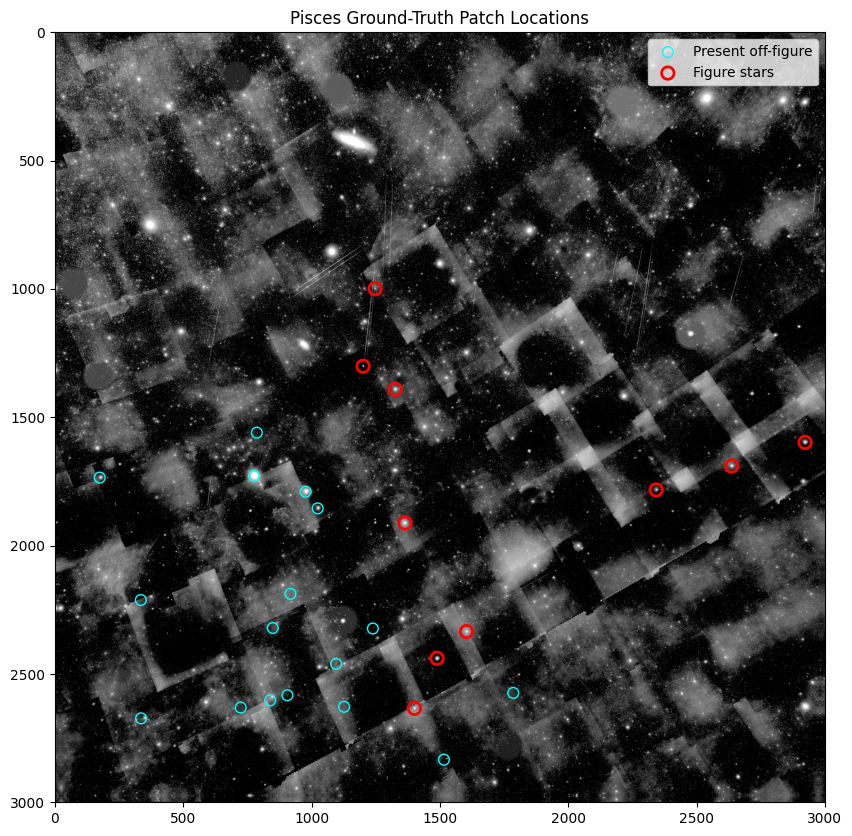

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(scene, cmap="gray")

figure_x = []
figure_y = []

off_x = []
off_y = []

for info in parsed_truth.values():

    if not info["present"]:
        continue

    if info["m"] == 1:
        figure_x.append(info["x"])
        figure_y.append(info["y"])

    elif info["m"] == 0:
        off_x.append(info["x"])
        off_y.append(info["y"])


plt.scatter(
    off_x,
    off_y,
    s=60,
    facecolors="none",
    edgecolors="cyan",
    label="Present off-figure"
)

plt.scatter(
    figure_x,
    figure_y,
    s=80,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Figure stars"
)

plt.title("Pisces Ground-Truth Patch Locations")
plt.legend()

plt.xlim(0, scene.shape[1])
plt.ylim(scene.shape[0], 0)

plt.show()

In [ ]:
patch_name = "patch_02"

info = parsed_truth[patch_name]

x = int(info["x"])
y = int(info["y"])

query_path = patch_dir / f"{patch_name}.png"

query = np.array(
    Image.open(query_path).convert("L")
)

half = 16

scene_crop = scene[
    y-half:y+half,
    x-half:x+half
]

print("Query shape:", query.shape)
print("Scene crop shape:", scene_crop.shape)
print("Ground-truth center:", (x, y))
print("Figure membership m:", info["m"])

Query shape: (32, 32)
Scene crop shape: (32, 32)
Ground-truth center: (2343, 1783)
Figure membership m: 1


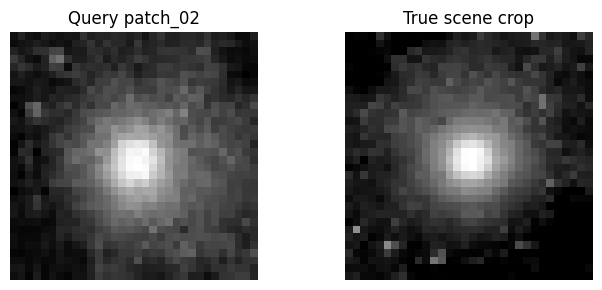

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].imshow(query, cmap="gray")
axes[0].set_title("Query patch_02")
axes[0].axis("off")

axes[1].imshow(scene_crop, cmap="gray")
axes[1].set_title("True scene crop")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def normalize_patch(patch):
    patch = patch.astype(np.float32)

    mean = patch.mean()
    std = patch.std()

    return (patch - mean) / (std + 1e-8)


def correlation_score(a, b):
    a_norm = normalize_patch(a)
    b_norm = normalize_patch(b)

    return np.mean(a_norm * b_norm)

In [ ]:
score_true = correlation_score(
    query,
    scene_crop
)

print("Correlation with true crop:", score_true)

Correlation with true crop: 0.8316357


In [ ]:
wrong_x = 500
wrong_y = 500

wrong_crop = scene[
    wrong_y-16:wrong_y+16,
    wrong_x-16:wrong_x+16
]

score_wrong = correlation_score(
    query,
    wrong_crop
)

print("True crop score :", score_true)
print("Wrong crop score:", score_wrong)

True crop score : 0.8316357
Wrong crop score: 0.054372337


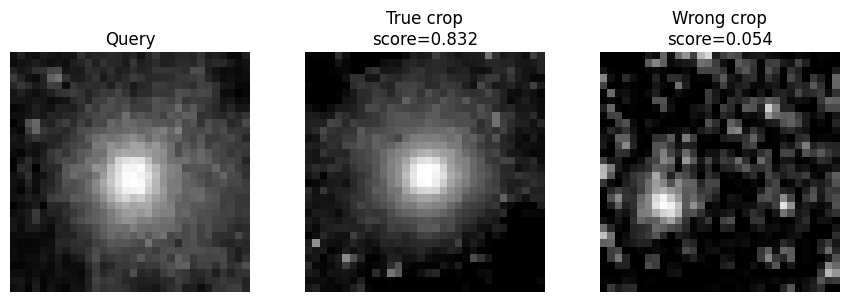

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(query, cmap="gray")
axes[0].set_title("Query")
axes[0].axis("off")

axes[1].imshow(scene_crop, cmap="gray")
axes[1].set_title(f"True crop\nscore={score_true:.3f}")
axes[1].axis("off")

axes[2].imshow(wrong_crop, cmap="gray")
axes[2].set_title(f"Wrong crop\nscore={score_wrong:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
rng = np.random.default_rng(42)

wrong_scores = []

num_samples = 200
half = 16

H, W = scene.shape

for _ in range(num_samples):

    wx = rng.integers(half, W - half)
    wy = rng.integers(half, H - half)

    if np.hypot(wx - x, wy - y) < 50:
        continue

    crop = scene[
        wy-half:wy+half,
        wx-half:wx+half
    ]

    score = correlation_score(
        query,
        crop
    )

    wrong_scores.append(score)

wrong_scores = np.array(wrong_scores)

print("True score:", score_true)
print("Mean wrong score:", wrong_scores.mean())
print("Highest wrong score:", wrong_scores.max())
print("95th percentile wrong score:", np.percentile(wrong_scores, 95))

True score: 0.8316357
Mean wrong score: -0.0030388557
Highest wrong score: 0.4445777
95th percentile wrong score: 0.26058742


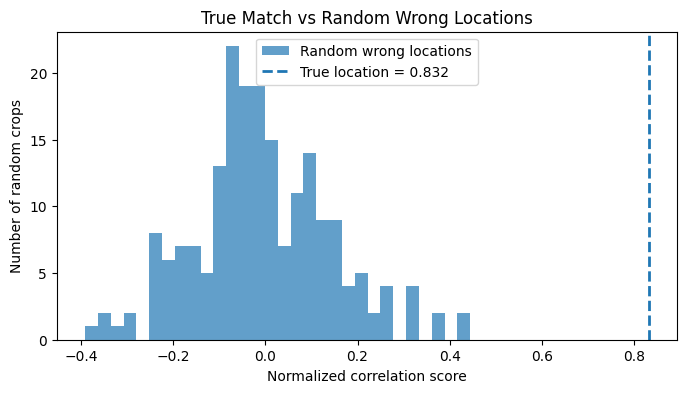

In [ ]:
plt.figure(figsize=(8, 4))

plt.hist(
    wrong_scores,
    bins=30,
    alpha=0.7,
    label="Random wrong locations"
)

plt.axvline(
    score_true,
    linestyle="--",
    linewidth=2,
    label=f"True location = {score_true:.3f}"
)

plt.xlabel("Normalized correlation score")
plt.ylabel("Number of random crops")
plt.title("True Match vs Random Wrong Locations")
plt.legend()

plt.show()

In [ ]:
results = []

for patch_name, info in parsed_truth.items():

    if not info["present"]:
        continue

    x_true = int(info["x"])
    y_true = int(info["y"])

    query_path = patch_dir / f"{patch_name}.png"
    q = np.array(
        Image.open(query_path).convert("L")
    )

    crop = scene[
        y_true-16:y_true+16,
        x_true-16:x_true+16
    ]

    if crop.shape != q.shape:
        continue

    score = correlation_score(q, crop)

    results.append({
        "patch": patch_name,
        "m": info["m"],
        "x": x_true,
        "y": y_true,
        "true_score": score
    })

In [ ]:
true_score_df = pd.DataFrame(results)

display(
    true_score_df.sort_values(
        "true_score",
        ascending=True
    )
)

,patch,m,x,y,true_score
0,patch_01,0,906,2583,-0.291771
18,patch_26,0,1127,2628,-0.282221
9,patch_12,0,336,2673,-0.264530
4,patch_06,0,1096,2461,-0.244401
7,patch_09,0,335,2212,-0.226408
26,patch_39,0,787,1560,-0.159346
11,patch_16,0,849,2321,-0.155682
2,patch_03,0,1516,2834,-0.136955
13,patch_18,0,918,2188,0.062819
14,patch_19,0,1239,2323,0.087869


In [ ]:
print("Number of present patches:", len(true_score_df))
print("Minimum true score:", true_score_df["true_score"].min())
print("Median true score:", true_score_df["true_score"].median())
print("Mean true score:", true_score_df["true_score"].mean())
print("Maximum true score:", true_score_df["true_score"].max())

Number of present patches: 27
Minimum true score: -0.29177141189575195
Median true score: 0.4147423505783081
Mean true score: 0.36525178
Maximum true score: 0.9271447658538818


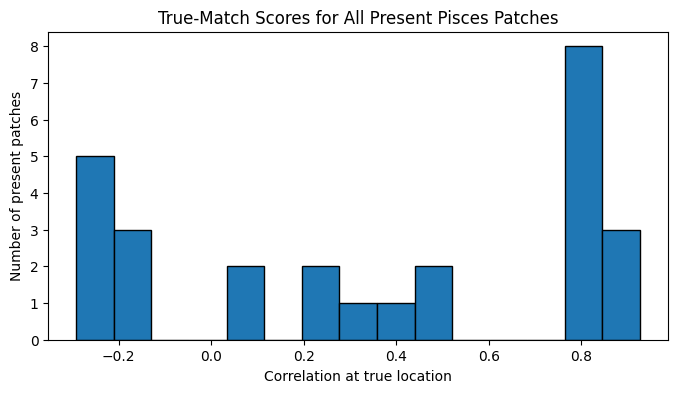

In [ ]:
plt.figure(figsize=(8, 4))

plt.hist(
    true_score_df["true_score"],
    bins=15,
    edgecolor="black"
)

plt.xlabel("Correlation at true location")
plt.ylabel("Number of present patches")
plt.title("True-Match Scores for All Present Pisces Patches")

plt.show()

In [ ]:
import cv2

patch_name = "patch_01"

info = parsed_truth[patch_name]

x_true = int(info["x"])
y_true = int(info["y"])

query_bad = np.array(
    Image.open(
        patch_dir / f"{patch_name}.png"
    ).convert("L")
)

true_crop_bad = scene[
    y_true-16:y_true+16,
    x_true-16:x_true+16
]

print(
    "Original score:",
    correlation_score(
        query_bad,
        true_crop_bad
    )
)

Original score: -0.2917714


In [ ]:
def rotate_patch(patch, angle):
    h, w = patch.shape

    center = (
        (w - 1) / 2,
        (h - 1) / 2
    )

    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    rotated = cv2.warpAffine(
        patch,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )

    return rotated

In [ ]:
angles = np.arange(
    0,
    360,
    10
)

rotation_scores = []

for angle in angles:

    rotated = rotate_patch(
        query_bad,
        angle
    )

    score = correlation_score(
        rotated,
        true_crop_bad
    )

    rotation_scores.append(score)

rotation_scores = np.array(
    rotation_scores
)

best_index = np.argmax(
    rotation_scores
)

best_angle = angles[best_index]
best_score = rotation_scores[best_index]

print("Original score:",
      correlation_score(query_bad, true_crop_bad))

print("Best angle:", best_angle)
print("Best rotated score:", best_score)

Original score: -0.2917714
Best angle: 230
Best rotated score: 0.7175847


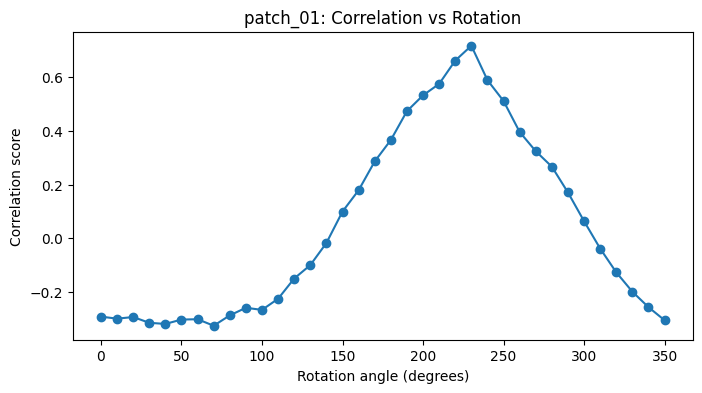

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(
    angles,
    rotation_scores,
    marker="o"
)

plt.xlabel("Rotation angle (degrees)")
plt.ylabel("Correlation score")
plt.title("patch_01: Correlation vs Rotation")

plt.show()

In [ ]:
angles = np.arange(0, 360, 10)

rotation_results = []

for patch_name, info in parsed_truth.items():

    if not info["present"]:
        continue

    x_true = int(info["x"])
    y_true = int(info["y"])

    q = np.array(
        Image.open(
            patch_dir / f"{patch_name}.png"
        ).convert("L")
    )

    true_crop = scene[
        y_true-16:y_true+16,
        x_true-16:x_true+16
    ]

    if true_crop.shape != q.shape:
        continue

    original_score = correlation_score(
        q,
        true_crop
    )

    best_score = -np.inf
    best_angle = None

    for angle in angles:

        rotated = rotate_patch(
            q,
            angle
        )

        score = correlation_score(
            rotated,
            true_crop
        )

        if score > best_score:
            best_score = score
            best_angle = angle

    rotation_results.append({
        "patch": patch_name,
        "m": info["m"],
        "original_score": original_score,
        "best_rotated_score": best_score,
        "best_angle": best_angle
    })

In [ ]:
rotation_df = pd.DataFrame(rotation_results)

display(
    rotation_df.sort_values(
        "best_rotated_score"
    )
)

,patch,m,original_score,best_rotated_score,best_angle
13,patch_18,0,0.062819,0.457484,120
18,patch_26,0,-0.282221,0.499587,210
14,patch_19,0,0.087869,0.531583,200
19,patch_28,0,0.269015,0.536927,30
5,patch_07,0,0.206166,0.551522,20
26,patch_39,0,-0.159346,0.651340,150
3,patch_04,1,0.462061,0.671187,20
11,patch_16,0,-0.155682,0.678417,160
4,patch_06,0,-0.244401,0.707243,100
0,patch_01,0,-0.291771,0.717585,230


In [ ]:
print("Original median score:",
      rotation_df["original_score"].median())

print("Rotated median score:",
      rotation_df["best_rotated_score"].median())

print("Original minimum score:",
      rotation_df["original_score"].min())

print("Rotated minimum score:",
      rotation_df["best_rotated_score"].min())

Original median score: 0.4147423505783081
Rotated median score: 0.8788511753082275
Original minimum score: -0.29177141189575195
Rotated minimum score: 0.4574844241142273


In [ ]:
def transform_patch(patch, angle, scale):
    h, w = patch.shape

    center = (
        (w - 1) / 2,
        (h - 1) / 2
    )

    M = cv2.getRotationMatrix2D(
        center,
        angle,
        scale
    )

    transformed = cv2.warpAffine(
        patch,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )

    return transformed

In [ ]:
patch_name = "patch_18"

info = parsed_truth[patch_name]

x_true = int(info["x"])
y_true = int(info["y"])

q = np.array(
    Image.open(
        patch_dir / f"{patch_name}.png"
    ).convert("L")
)

true_crop = scene[
    y_true-16:y_true+16,
    x_true-16:x_true+16
]

In [ ]:
angles = np.arange(0, 360, 10)

scales = np.arange(
    0.80,
    1.21,
    0.05
)

best_score = -np.inf
best_angle = None
best_scale = None

for scale in scales:

    for angle in angles:

        transformed = transform_patch(
            q,
            angle,
            scale
        )

        score = correlation_score(
            transformed,
            true_crop
        )

        if score > best_score:
            best_score = score
            best_angle = angle
            best_scale = scale


print("Rotation-only best score: 0.457")
print("Best rotation + scale score:", best_score)
print("Best angle:", best_angle)
print("Best scale:", best_scale)

Rotation-only best score: 0.457
Best rotation + scale score: 0.6307242
Best angle: 120
Best scale: 0.9000000000000001


In [ ]:
angles = np.arange(0, 360, 10)

scales = np.arange(
    0.80,
    1.21,
    0.05
)

transform_results = []

for patch_name, info in parsed_truth.items():

    if not info["present"]:
        continue

    x_true = int(info["x"])
    y_true = int(info["y"])

    q = np.array(
        Image.open(
            patch_dir / f"{patch_name}.png"
        ).convert("L")
    )

    true_crop = scene[
        y_true-16:y_true+16,
        x_true-16:x_true+16
    ]

    if true_crop.shape != q.shape:
        continue

    best_score = -np.inf
    best_angle = None
    best_scale = None

    for scale in scales:
        for angle in angles:

            transformed = transform_patch(
                q,
                angle,
                scale
            )

            score = correlation_score(
                transformed,
                true_crop
            )

            if score > best_score:
                best_score = score
                best_angle = angle
                best_scale = scale

    transform_results.append({
        "patch": patch_name,
        "m": info["m"],
        "best_score": best_score,
        "best_angle": best_angle,
        "best_scale": best_scale
    })

In [ ]:
transform_df = pd.DataFrame(
    transform_results
)

display(
    transform_df.sort_values(
        "best_score"
    )
)

,patch,m,best_score,best_angle,best_scale
5,patch_07,0,0.551522,20,1.00
19,patch_28,0,0.572741,40,1.15
18,patch_26,0,0.589178,200,1.10
14,patch_19,0,0.597391,200,0.90
13,patch_18,0,0.630724,120,0.90
26,patch_39,0,0.651340,150,1.00
11,patch_16,0,0.678417,160,1.00
4,patch_06,0,0.728675,100,0.95
3,patch_04,1,0.737654,20,0.95
2,patch_03,0,0.746975,60,1.10


In [ ]:
print(
    "Minimum score:",
    transform_df["best_score"].min()
)

print(
    "Median score:",
    transform_df["best_score"].median()
)

print(
    "Mean score:",
    transform_df["best_score"].mean()
)

print(
    "Maximum score:",
    transform_df["best_score"].max()
)

Minimum score: 0.5515220165252686
Median score: 0.8830944299697876
Mean score: 0.81292653
Maximum score: 0.9648757576942444


In [ ]:
patch_name = "patch_07"

info = parsed_truth[patch_name]

x_true = int(info["x"])
y_true = int(info["y"])

q = np.array(
    Image.open(
        patch_dir / f"{patch_name}.png"
    ).convert("L")
)

true_crop = scene[
    y_true-16:y_true+16,
    x_true-16:x_true+16
]

In [ ]:
def transform_patch(patch, angle, scale, dx=0, dy=0):
    h, w = patch.shape

    center = (
        (w - 1) / 2,
        (h - 1) / 2
    )

    M = cv2.getRotationMatrix2D(
        center,
        angle,
        scale
    )

    M[0, 2] += dx
    M[1, 2] += dy

    transformed = cv2.warpAffine(
        patch,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )

    return transformed

In [ ]:
angles = np.arange(0, 360, 10)

scales = np.arange(
    0.80,
    1.21,
    0.05
)

shifts = [-1, 0, 1]

best_score = -np.inf
best_params = None

for scale in scales:
    for angle in angles:
        for dx in shifts:
            for dy in shifts:

                transformed = transform_patch(
                    q,
                    angle,
                    scale,
                    dx,
                    dy
                )

                score = correlation_score(
                    transformed,
                    true_crop
                )

                if score > best_score:
                    best_score = score
                    best_params = (
                        angle,
                        scale,
                        dx,
                        dy
                    )

print("Previous best score: 0.552")
print("Best score with shifts:", best_score)
print("Best parameters:", best_params)

Previous best score: 0.552
Best score with shifts: 0.76992524
Best parameters: (np.int64(20), np.float64(1.0500000000000003), 1, 1)


In [ ]:
angles = np.arange(0, 360, 10)

scales = np.arange(0.80, 1.21, 0.05)

shifts = [-1, 0, 1]

full_results = []

for patch_name, info in parsed_truth.items():

    if not info["present"]:
        continue

    x_true = int(info["x"])
    y_true = int(info["y"])

    q = np.array(
        Image.open(
            patch_dir / f"{patch_name}.png"
        ).convert("L")
    )

    true_crop = scene[
        y_true-16:y_true+16,
        x_true-16:x_true+16
    ]

    if true_crop.shape != q.shape:
        continue

    best_score = -np.inf
    best_angle = None
    best_scale = None
    best_dx = None
    best_dy = None

    for scale in scales:
        for angle in angles:
            for dx in shifts:
                for dy in shifts:

                    transformed = transform_patch(
                        q,
                        angle,
                        scale,
                        dx,
                        dy
                    )

                    score = correlation_score(
                        transformed,
                        true_crop
                    )

                    if score > best_score:
                        best_score = score
                        best_angle = angle
                        best_scale = scale
                        best_dx = dx
                        best_dy = dy

    full_results.append({
        "patch": patch_name,
        "m": info["m"],
        "best_score": best_score,
        "best_angle": best_angle,
        "best_scale": best_scale,
        "best_dx": best_dx,
        "best_dy": best_dy
    })

In [ ]:
full_df = pd.DataFrame(full_results)

display(
    full_df.sort_values("best_score")
)

,patch,m,best_score,best_angle,best_scale,best_dx,best_dy
18,patch_26,0,0.589178,200,1.10,0,0
13,patch_18,0,0.630724,120,0.90,0,0
26,patch_39,0,0.651340,150,1.00,0,0
19,patch_28,0,0.706724,40,1.05,1,1
0,patch_01,0,0.750898,230,1.05,0,0
5,patch_07,0,0.769925,20,1.05,1,1
3,patch_04,1,0.778998,20,1.00,1,0
4,patch_06,0,0.806799,100,0.95,1,0
14,patch_19,0,0.815397,200,0.90,0,1
11,patch_16,0,0.820330,160,0.95,1,0


In [ ]:
print("Minimum score:", full_df["best_score"].min())
print("Median score:", full_df["best_score"].median())
print("Mean score:", full_df["best_score"].mean())
print("Maximum score:", full_df["best_score"].max())

Minimum score: 0.589178204536438
Median score: 0.9120581150054932
Mean score: 0.8618671
Maximum score: 0.9808679819107056


In [ ]:
def best_transform_score(query, crop):
    angles = np.arange(0, 360, 10)
    scales = np.arange(0.80, 1.21, 0.05)
    shifts = [-1, 0, 1]

    best_score = -np.inf
    best_params = None

    for scale in scales:
        for angle in angles:
            for dx in shifts:
                for dy in shifts:

                    transformed = transform_patch(
                        query,
                        angle,
                        scale,
                        dx,
                        dy
                    )

                    score = correlation_score(
                        transformed,
                        crop
                    )

                    if score > best_score:
                        best_score = score
                        best_params = (
                            angle,
                            scale,
                            dx,
                            dy
                        )

    return best_score, best_params

In [ ]:
patch_name = "patch_26"

info = parsed_truth[patch_name]

x_true = int(info["x"])
y_true = int(info["y"])

q = np.array(
    Image.open(
        patch_dir / f"{patch_name}.png"
    ).convert("L")
)

true_crop = scene[
    y_true-16:y_true+16,
    x_true-16:x_true+16
]

true_best_score, true_params = best_transform_score(
    q,
    true_crop
)

print("True-location score:", true_best_score)
print("True-location parameters:", true_params)

True-location score: 0.5891782
True-location parameters: (np.int64(200), np.float64(1.1000000000000003), 0, 0)


In [ ]:
rng = np.random.default_rng(42)

wrong_scores = []

H, W = scene.shape
half = 16

while len(wrong_scores) < 20:

    wx = rng.integers(half, W - half)
    wy = rng.integers(half, H - half)

    # Stay well away from the known true location
    if np.hypot(
        wx - x_true,
        wy - y_true
    ) < 100:
        continue

    wrong_crop = scene[
        wy-half:wy+half,
        wx-half:wx+half
    ]

    wrong_score, _ = best_transform_score(
        q,
        wrong_crop
    )

    wrong_scores.append(
        wrong_score
    )

wrong_scores = np.array(wrong_scores)

print("\nTrue score:", true_best_score)
print("Mean wrong score:", wrong_scores.mean())
print("Highest wrong score:", wrong_scores.max())


True score: 0.5891782
Mean wrong score: 0.33069846
Highest wrong score: 0.56596506


In [ ]:
import cv2
import numpy as np

def detect_star_candidates(scene):
    gray = scene.astype(np.float32)

    background = cv2.GaussianBlur(
        gray,
        (0, 0),
        sigmaX=3.0
    )

    highpass = gray - background

    median = np.median(highpass)

    mad = np.median(
        np.abs(highpass - median)
    )

    sigma = 1.4826 * mad + 1e-8

    threshold = median + 5.0 * sigma

    local_max = cv2.dilate(
        highpass,
        np.ones((3, 3), dtype=np.uint8)
    )

    peaks = (
        (highpass == local_max)
        &
        (highpass > threshold)
    )

    y_coords, x_coords = np.nonzero(peaks)

    candidates = np.column_stack(
        [x_coords, y_coords]
    )

    return candidates, highpass

In [ ]:
candidates, highpass = detect_star_candidates(scene)

print("Candidate stars detected:", len(candidates))

Candidate stars detected: 167975


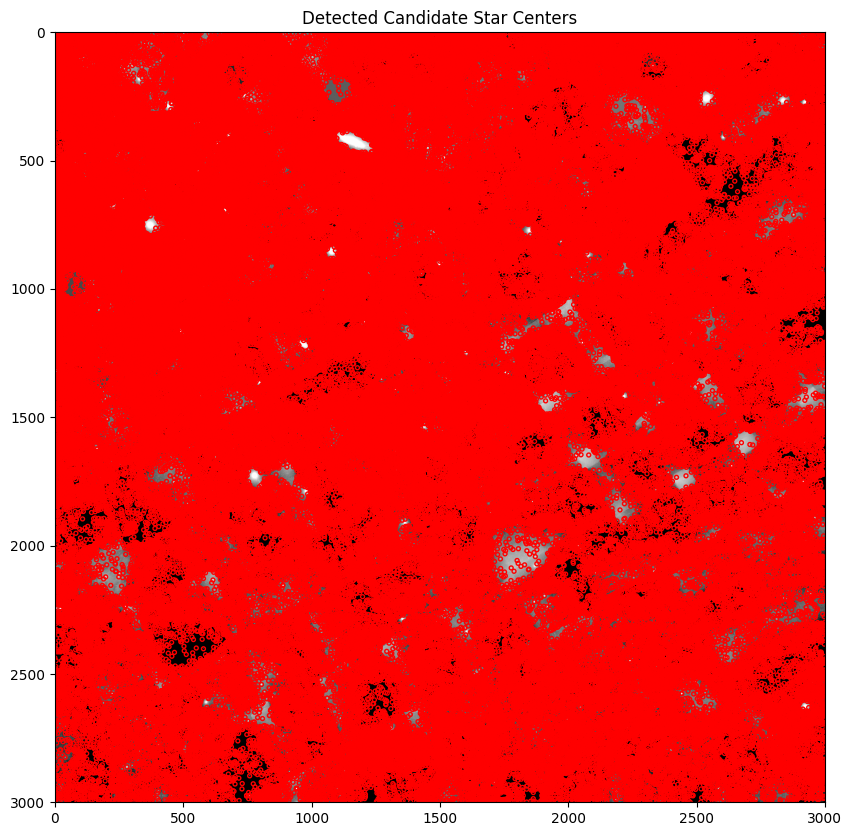

In [ ]:
plt.figure(figsize=(10, 10))

plt.imshow(scene, cmap="gray")

plt.scatter(
    candidates[:, 0],
    candidates[:, 1],
    s=8,
    facecolors="none",
    edgecolors="red"
)

plt.title("Detected Candidate Star Centers")
plt.xlim(0, scene.shape[1])
plt.ylim(scene.shape[0], 0)

plt.show()

In [ ]:
from scipy.spatial import cKDTree

true_points = []

for patch_name, info in parsed_truth.items():
    if info["present"]:
        true_points.append([
            info["x"],
            info["y"]
        ])

true_points = np.array(true_points)

tree = cKDTree(candidates)

distances, indices = tree.query(
    true_points,
    k=1
)

print("Total detected candidates:", len(candidates))

print("\nTrue-star recovery:")
for radius in [1, 2, 3, 5]:
    recovered = np.sum(distances <= radius)

    print(
        f"Within {radius} px: "
        f"{recovered}/27"
    )

print("\nWorst distance to nearest candidate:",
      distances.max())

Total detected candidates: 167975

True-star recovery:
Within 1 px: 15/27
Within 2 px: 18/27
Within 3 px: 20/27
Within 5 px: 21/27

Worst distance to nearest candidate: 27.018512172212592


In [ ]:

median_hp = np.median(highpass)
mad_hp = np.median(np.abs(highpass - median_hp))
sigma_hp = 1.4826 * mad_hp + 1e-8
threshold_hp = median_hp + 5.0 * sigma_hp

rows = []

for patch_name, info in parsed_truth.items():

    if not info["present"]:
        continue

    x = int(info["x"])
    y = int(info["y"])

    distance, _ = tree.query([x, y])

    r = 5

    local = highpass[
        max(0, y-r):min(scene.shape[0], y+r+1),
        max(0, x-r):min(scene.shape[1], x+r+1)
    ]

    rows.append({
        "patch": patch_name,
        "m": info["m"],
        "nearest_candidate_dist": distance,
        "highpass_at_true_center": highpass[y, x],
        "max_highpass_within_5px": local.max(),
        "max_above_threshold": local.max() > threshold_hp
    })

diagnostic_df = pd.DataFrame(rows)

display(
    diagnostic_df.sort_values(
        "nearest_candidate_dist",
        ascending=False
    )
)

print("Detector threshold:", threshold_hp)

,patch,m,nearest_candidate_dist,highpass_at_true_center,max_highpass_within_5px,max_above_threshold
17,patch_22,0,27.018512,0.530548,7.188980,False
22,patch_33,1,13.341664,21.446381,33.583542,False
23,patch_34,1,13.341664,36.639938,45.227173,False
24,patch_35,0,12.041595,11.558182,30.965500,False
13,patch_18,0,10.000000,39.053772,39.053772,False
19,patch_28,0,6.324555,41.314728,41.314728,False
12,patch_17,0,4.123106,-3.267029,111.762177,True
16,patch_21,1,2.236068,44.448944,54.219559,True
25,patch_37,1,2.236068,50.067764,59.802490,True
21,patch_32,1,2.000000,48.932037,62.030457,True


Detector threshold: 46.324627


In [ ]:
missed = diagnostic_df[
    diagnostic_df["nearest_candidate_dist"] > 5
]["patch"].tolist()

print("Missed patches:", missed)

Missed patches: ['patch_18', 'patch_22', 'patch_28', 'patch_33', 'patch_34', 'patch_35']


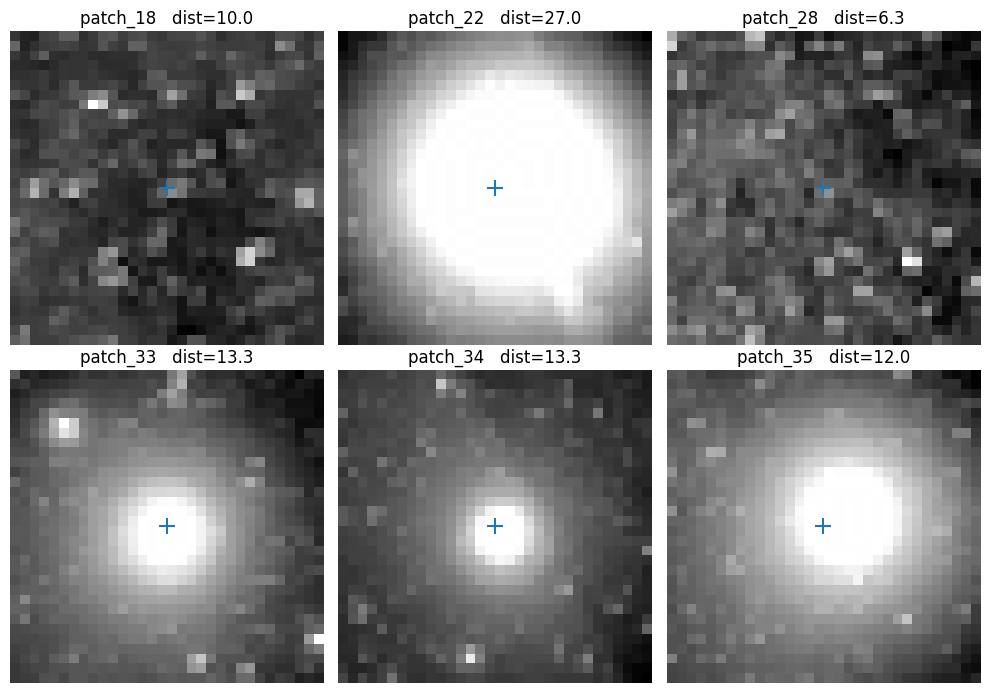

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 7)
)

for ax, patch_name in zip(
    axes.ravel(),
    missed
):
    info = parsed_truth[patch_name]

    x = int(info["x"])
    y = int(info["y"])

    crop = scene[
        y-16:y+16,
        x-16:x+16
    ]

    ax.imshow(
        crop,
        cmap="gray"
    )

    # Ground-truth center
    ax.scatter(
        15.5,
        15.5,
        marker="+",
        s=120
    )

    ax.set_title(
        f"{patch_name}   dist={diagnostic_df.loc[diagnostic_df['patch']==patch_name, 'nearest_candidate_dist'].iloc[0]:.1f}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
sigmas = [1.5, 3, 6, 10]

for patch_name in missed:

    info = parsed_truth[patch_name]

    x = int(info["x"])
    y = int(info["y"])

    print(f"\n{patch_name}")

    for sigma in sigmas:

        background = cv2.GaussianBlur(
            scene.astype(np.float32),
            (0, 0),
            sigmaX=sigma
        )

        response = (
            scene.astype(np.float32)
            - background
        )

        local = response[
            y-5:y+6,
            x-5:x+6
        ]

        print(
            f"  sigma={sigma:>4}: "
            f"max response = {local.max():.2f}"
        )


patch_18
  sigma= 1.5: max response = 33.17
  sigma=   3: max response = 39.05
  sigma=   6: max response = 38.36
  sigma=  10: max response = 36.64

patch_22
  sigma= 1.5: max response = 1.52
  sigma=   3: max response = 7.19
  sigma=   6: max response = 20.88
  sigma=  10: max response = 45.21

patch_28
  sigma= 1.5: max response = 36.04
  sigma=   3: max response = 41.31
  sigma=   6: max response = 42.73
  sigma=  10: max response = 44.59

patch_33
  sigma= 1.5: max response = 15.68
  sigma=   3: max response = 33.58
  sigma=   6: max response = 69.44
  sigma=  10: max response = 105.04

patch_34
  sigma= 1.5: max response = 22.92
  sigma=   3: max response = 45.23
  sigma=   6: max response = 78.32
  sigma=  10: max response = 102.97

patch_35
  sigma= 1.5: max response = 21.71
  sigma=   3: max response = 30.97
  sigma=   6: max response = 57.72
  sigma=  10: max response = 99.21


In [ ]:
sigmas = [1.5, 3, 6, 10]

gray = scene.astype(np.float32)

multi_score = np.full(
    gray.shape,
    -np.inf,
    dtype=np.float32
)

for sigma in sigmas:

    background = cv2.GaussianBlur(
        gray,
        (0, 0),
        sigmaX=sigma
    )

    response = gray - background

    med = np.median(response)

    mad = np.median(
        np.abs(response - med)
    )

    robust_std = 1.4826 * mad + 1e-8

    z = (response - med) / robust_std

    multi_score = np.maximum(
        multi_score,
        z
    )

In [ ]:
multi_rows = []

for patch_name, info in parsed_truth.items():

    if not info["present"]:
        continue

    x = int(info["x"])
    y = int(info["y"])

    r = 5

    local = multi_score[
        y-r:y+r+1,
        x-r:x+r+1
    ]

    multi_rows.append({
        "patch": patch_name,
        "m": info["m"],
        "multi_score_center": multi_score[y, x],
        "multi_score_within_5px": local.max()
    })

multi_df = pd.DataFrame(multi_rows)

display(
    multi_df.sort_values(
        "multi_score_within_5px"
    )
)

,patch,m,multi_score_center,multi_score_within_5px
17,patch_22,0,2.726156,3.599740
13,patch_18,0,4.265241,4.265241
19,patch_28,0,4.556068,4.556068
7,patch_09,0,6.332941,6.332941
5,patch_07,0,6.794451,6.794451
24,patch_35,0,6.585946,7.543161
9,patch_12,0,7.677990,7.677990
23,patch_34,1,7.701294,7.817776
22,patch_33,1,7.699968,7.968913
18,patch_26,0,8.225411,8.225411


In [ ]:
print(
    "Weakest true star:",
    multi_df["multi_score_within_5px"].min()
)

print(
    "Median true star:",
    multi_df["multi_score_within_5px"].median()
)

print("\nWhole-image score percentiles:")

for p in [95, 99, 99.5, 99.9, 99.95]:
    print(
        p,
        np.percentile(multi_score, p)
    )

Weakest true star: 3.5997400283813477
Median true star: 11.057788848876953

Whole-image score percentiles:
95 4.6414557
99 9.285747
99.5 11.3655815
99.9 15.810789
99.95 17.481703


In [ ]:
def make_candidates(score_map, threshold, nms_size=7):

    kernel = np.ones(
        (nms_size, nms_size),
        dtype=np.uint8
    )

    local_max = cv2.dilate(
        score_map,
        kernel
    )

    peaks = (
        (score_map == local_max)
        &
        (score_map >= threshold)
    )

    ys, xs = np.nonzero(peaks)

    return np.column_stack([xs, ys])

In [ ]:
thresholds = [2.5, 3.0, 3.5, 4.0, 5.0]

for threshold in thresholds:

    cand = make_candidates(
        multi_score,
        threshold,
        nms_size=7
    )

    tree_test = cKDTree(cand)

    distances, _ = tree_test.query(
        true_points,
        k=1
    )

    within_5 = np.sum(distances <= 5)
    within_12 = np.sum(distances <= 12)

    print(
        f"threshold={threshold:3.1f} | "
        f"candidates={len(cand):6d} | "
        f"within 5px={within_5}/27 | "
        f"within 12px={within_12}/27"
    )

threshold=2.5 | candidates=152898 | within 5px=24/27 | within 12px=27/27
threshold=3.0 | candidates=147233 | within 5px=24/27 | within 12px=27/27
threshold=3.5 | candidates=140354 | within 5px=24/27 | within 12px=27/27
threshold=4.0 | candidates=132320 | within 5px=24/27 | within 12px=27/27
threshold=5.0 | candidates=115059 | within 5px=22/27 | within 12px=26/27


In [ ]:
for nms_size in [7, 11, 15, 21, 31]:

    cand = make_candidates(
        multi_score,
        threshold=3.5,
        nms_size=nms_size
    )

    tree_test = cKDTree(cand)

    distances, _ = tree_test.query(
        true_points,
        k=1
    )

    within_5 = np.sum(distances <= 5)
    within_12 = np.sum(distances <= 12)

    print(
        f"NMS={nms_size:2d} | "
        f"candidates={len(cand):6d} | "
        f"within 5px={within_5}/27 | "
        f"within 12px={within_12}/27"
    )

NMS= 7 | candidates=140354 | within 5px=24/27 | within 12px=27/27
NMS=11 | candidates= 67564 | within 5px=24/27 | within 12px=27/27
NMS=15 | candidates= 37870 | within 5px=18/27 | within 12px=27/27
NMS=21 | candidates= 19692 | within 5px=17/27 | within 12px=27/27
NMS=31 | candidates=  9002 | within 5px=12/27 | within 12px=18/27


In [ ]:
def radial_profile(patch):
    h, w = patch.shape

    yy, xx = np.indices((h, w))

    cx = (w - 1) / 2
    cy = (h - 1) / 2

    r = np.sqrt(
        (xx - cx)**2 +
        (yy - cy)**2
    )

    r_int = r.astype(int)

    profile = []

    for radius in range(16):
        mask = (r_int == radius)

        if np.any(mask):
            profile.append(
                patch[mask].mean()
            )

    profile = np.array(
        profile,
        dtype=np.float32
    )

    profile = (
        profile - profile.mean()
    ) / (
        profile.std() + 1e-8
    )

    return profile

In [ ]:
patch_name = "patch_26"

info = parsed_truth[patch_name]

x_true = int(info["x"])
y_true = int(info["y"])

q = np.array(
    Image.open(
        patch_dir / f"{patch_name}.png"
    ).convert("L")
)

true_crop = scene[
    y_true-16:y_true+16,
    x_true-16:x_true+16
]

q_profile = radial_profile(q)
true_profile = radial_profile(true_crop)

profile_score = np.mean(
    q_profile * true_profile
)

print(
    "True-location radial-profile score:",
    profile_score
)

True-location radial-profile score: 0.8612245


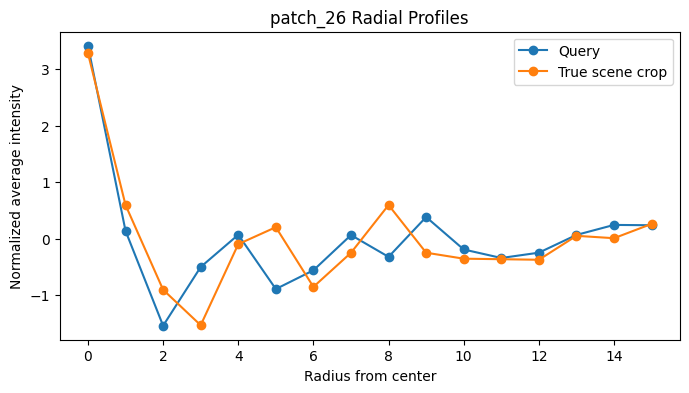

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(
    q_profile,
    marker="o",
    label="Query"
)

plt.plot(
    true_profile,
    marker="o",
    label="True scene crop"
)

plt.xlabel("Radius from center")
plt.ylabel("Normalized average intensity")
plt.title("patch_26 Radial Profiles")

plt.legend()
plt.show()

In [ ]:
candidates_21 = make_candidates(
    multi_score,
    threshold=3.5,
    nms_size=21
)

print("Candidates:", len(candidates_21))

Candidates: 19692


In [ ]:
patch_name = "patch_26"

info = parsed_truth[patch_name]

x_true = int(info["x"])
y_true = int(info["y"])

q = np.array(
    Image.open(
        patch_dir / f"{patch_name}.png"
    ).convert("L")
)

q_profile = radial_profile(q)

ranked = []

for x, y in candidates_21:

    x = int(x)
    y = int(y)

    # Need a complete 32x32 crop
    if (
        x < 16 or x >= scene.shape[1] - 16 or
        y < 16 or y >= scene.shape[0] - 16
    ):
        continue

    crop = scene[
        y-16:y+16,
        x-16:x+16
    ]

    crop_profile = radial_profile(crop)

    score = np.mean(
        q_profile * crop_profile
    )

    ranked.append(
        (score, x, y)
    )

ranked.sort(reverse=True)

In [ ]:
top_candidates = ranked[:100]

print("Best radial score:", top_candidates[0][0])

# Find where a candidate close to the true location appears
true_rank = None
true_distance = None

for rank, (score, x, y) in enumerate(ranked, start=1):

    dist = np.hypot(
        x - x_true,
        y - y_true
    )

    if dist <= 12:
        true_rank = rank
        true_distance = dist
        break

print("Rank of first candidate within 12 px of truth:", true_rank)
print("Its distance from truth:", true_distance)

Best radial score: 0.97237116
Rank of first candidate within 12 px of truth: 5222
Its distance from truth: 0.0


In [ ]:

candidates = make_candidates(
    multi_score,
    threshold=3.5,
    nms_size=21
)

H, W = scene.shape

valid = (
    (candidates[:, 0] >= 16) &
    (candidates[:, 0] < W - 16) &
    (candidates[:, 1] >= 16) &
    (candidates[:, 1] < H - 16)
)

candidates = candidates[valid]

print("Candidates:", len(candidates))


candidate_crops = np.stack([
    scene[
        y-16:y+16,
        x-16:x+16
    ]
    for x, y in candidates
]).astype(np.float32)


candidate_vectors = candidate_crops.reshape(
    len(candidate_crops),
    -1
)


candidate_vectors -= candidate_vectors.mean(
    axis=1,
    keepdims=True
)

candidate_vectors /= (
    candidate_vectors.std(
        axis=1,
        keepdims=True
    ) + 1e-8
)

print("Candidate matrix:", candidate_vectors.shape)

Candidates: 19172
Candidate matrix: (19172, 1024)


In [ ]:
def coarse_search_query(query):

    transformed_queries = []
    params = []

    # Coarse search first
    angles = range(0, 360, 20)
    scales = [0.9, 1.0, 1.1]

    for scale in scales:
        for angle in angles:

            t = transform_patch(
                query,
                angle,
                scale
            ).astype(np.float32)

            v = t.ravel()

            v = (
                v - v.mean()
            ) / (
                v.std() + 1e-8
            )

            transformed_queries.append(v)
            params.append((angle, scale))

    transformed_queries = np.stack(
        transformed_queries
    )

    # 54 transformed queries × ~20k candidate crops
    scores = (
        transformed_queries
        @ candidate_vectors.T
    ) / (32 * 32)

    # Best transform for every candidate location
    best_scores = scores.max(axis=0)

    return best_scores, scores, params

In [ ]:
patch_name = "patch_26"

info = parsed_truth[patch_name]

x_true = int(info["x"])
y_true = int(info["y"])

q = np.array(
    Image.open(
        patch_dir / f"{patch_name}.png"
    ).convert("L")
)

best_scores, scores, params = coarse_search_query(q)

ranking = np.argsort(
    best_scores
)[::-1]

In [ ]:
true_rank = None
true_dist = None
true_candidate_score = None

for rank, idx in enumerate(ranking, start=1):

    x, y = candidates[idx]

    dist = np.hypot(
        x - x_true,
        y - y_true
    )

    if dist <= 12:
        true_rank = rank
        true_dist = dist
        true_candidate_score = best_scores[idx]
        break

print("Rank of candidate within 12 px:", true_rank)
print("Distance:", true_dist)
print("Score:", true_candidate_score)

print(
    "Best candidate score overall:",
    best_scores[ranking[0]]
)

Rank of candidate within 12 px: 5
Distance: 0.0
Score: 0.5891779
Best candidate score overall: 0.59662676


In [ ]:
def refine_top_candidates(
    query,
    best_scores,
    top_k=10
):
    # Top coarse candidates
    top_ids = np.argsort(best_scores)[::-1][:top_k]

    # Collect nearby possible centers
    fine_centers = []

    for idx in top_ids:
        x0, y0 = candidates[idx]

        # Candidate detector may be several pixels away
        # from the real query center
        for dx in range(-12, 13):
            for dy in range(-12, 13):

                x = int(x0 + dx)
                y = int(y0 + dy)

                if (
                    16 <= x < W - 16
                    and
                    16 <= y < H - 16
                ):
                    fine_centers.append((x, y))

    # Remove duplicates
    fine_centers = np.unique(
        np.array(fine_centers),
        axis=0
    )

    # Extract scene crops
    crops = np.stack([
        scene[
            y-16:y+16,
            x-16:x+16
        ]
        for x, y in fine_centers
    ]).astype(np.float32)

    crop_vectors = crops.reshape(
        len(crops),
        -1
    )

    crop_vectors -= crop_vectors.mean(
        axis=1,
        keepdims=True
    )

    crop_vectors /= (
        crop_vectors.std(
            axis=1,
            keepdims=True
        ) + 1e-8
    )

    # Finer transform grid
    transformed_queries = []
    transform_params = []

    for scale in np.arange(0.80, 1.21, 0.05):

        for angle in range(0, 360, 10):

            t = transform_patch(
                query,
                angle,
                scale
            ).astype(np.float32)

            v = t.ravel()

            v = (
                v - v.mean()
            ) / (
                v.std() + 1e-8
            )

            transformed_queries.append(v)
            transform_params.append(
                (angle, scale)
            )

    transformed_queries = np.stack(
        transformed_queries
    )

    # Compare every transform with every local center
    scores = (
        transformed_queries
        @ crop_vectors.T
    ) / (32 * 32)

    # Overall best combination
    transform_idx, center_idx = np.unravel_index(
        np.argmax(scores),
        scores.shape
    )

    best_angle, best_scale = (
        transform_params[transform_idx]
    )

    best_x, best_y = (
        fine_centers[center_idx]
    )

    return {
        "x": int(best_x),
        "y": int(best_y),
        "score": float(
            scores[transform_idx, center_idx]
        ),
        "angle": best_angle,
        "scale": best_scale
    }

In [ ]:
refined = refine_top_candidates(
    q,
    best_scores,
    top_k=10
)

distance = np.hypot(
    refined["x"] - x_true,
    refined["y"] - y_true
)

print("Predicted location:",
      refined["x"],
      refined["y"])

print("True location:",
      x_true,
      y_true)

print("Localization error:",
      distance)

print("Final score:",
      refined["score"])

print("Angle:",
      refined["angle"])

print("Scale:",
      refined["scale"])

Predicted location: 289 2226
True location: 1127 2628
Localization error: 929.4342365116534
Final score: 0.664598822593689
Angle: 270
Scale: 0.8


In [ ]:
topk_results = []

for patch_name, info in parsed_truth.items():

    if not info["present"]:
        continue

    query = np.array(
        Image.open(
            patch_dir / f"{patch_name}.png"
        ).convert("L")
    )

    best_scores, _, _ = coarse_search_query(query)

    ranking = np.argsort(best_scores)[::-1]

    x_true = int(info["x"])
    y_true = int(info["y"])

    true_rank = None
    true_distance = None

    for rank, idx in enumerate(ranking, start=1):

        x, y = candidates[idx]

        dist = np.hypot(
            x - x_true,
            y - y_true
        )

        if dist <= 12:
            true_rank = rank
            true_distance = dist
            break

    topk_results.append({
        "patch": patch_name,
        "m": info["m"],
        "true_rank": true_rank,
        "distance": true_distance
    })

    print(
        patch_name,
        "rank =", true_rank,
        "distance =", round(true_distance, 2)
        if true_distance is not None else None
    )

patch_01 rank = 602 distance = 0.0
patch_02 rank = 1 distance = 1.0
patch_03 rank = 12446 distance = 10.0
patch_04 rank = 2 distance = 0.0
patch_06 rank = 691 distance = 10.63
patch_07 rank = 4572 distance = 10.0
patch_08 rank = 10 distance = 5.1
patch_09 rank = 2 distance = 7.62
patch_11 rank = 35 distance = 2.0
patch_12 rank = 54 distance = 7.07
patch_13 rank = 17 distance = 3.61
patch_16 rank = 1 distance = 0.0
patch_17 rank = 108 distance = 4.12
patch_18 rank = 12486 distance = 10.0
patch_19 rank = 1 distance = 1.0
patch_20 rank = 2 distance = 1.41
patch_21 rank = 3 distance = 1.41
patch_22 rank = 52 distance = 11.18
patch_26 rank = 5 distance = 0.0
patch_28 rank = 4602 distance = 10.63
patch_29 rank = 2 distance = 0.0
patch_32 rank = 3 distance = 2.24
patch_33 rank = 37 distance = 2.24
patch_34 rank = 15 distance = 2.24
patch_35 rank = 44 distance = 6.71
patch_37 rank = 1 distance = 1.0
patch_39 rank = 1725 distance = 0.0


In [ ]:
topk_df = pd.DataFrame(topk_results)

for k in [1, 3, 5, 10, 20, 50, 100]:

    recovered = (
        topk_df["true_rank"] <= k
    ).sum()

    print(
        f"Top {k:3d}: "
        f"{recovered}/27"
    )

print(
    "\nMedian true rank:",
    topk_df["true_rank"].median()
)

print(
    "Worst true rank:",
    topk_df["true_rank"].max()
)

Top   1: 4/27
Top   3: 10/27
Top   5: 11/27
Top  10: 12/27
Top  20: 14/27
Top  50: 17/27
Top 100: 19/27

Median true rank: 17.0
Worst true rank: 12486


In [ ]:
pattern_paths = sorted(
    (DATA_ROOT / "patterns").glob("*")
)

print("Number of patterns:", len(pattern_paths))
print([p.name for p in pattern_paths[:10]])

Number of patterns: 48
['aquila_pattern.png', 'aries_pattern.png', 'auriga_pattern.png', 'bootes_pattern.png', 'caelum_pattern.png', 'camelopardalis_pattern.png', 'cancer_pattern.png', 'canis-major_pattern.png', 'carina_pattern.png', 'centaurus_pattern.png']


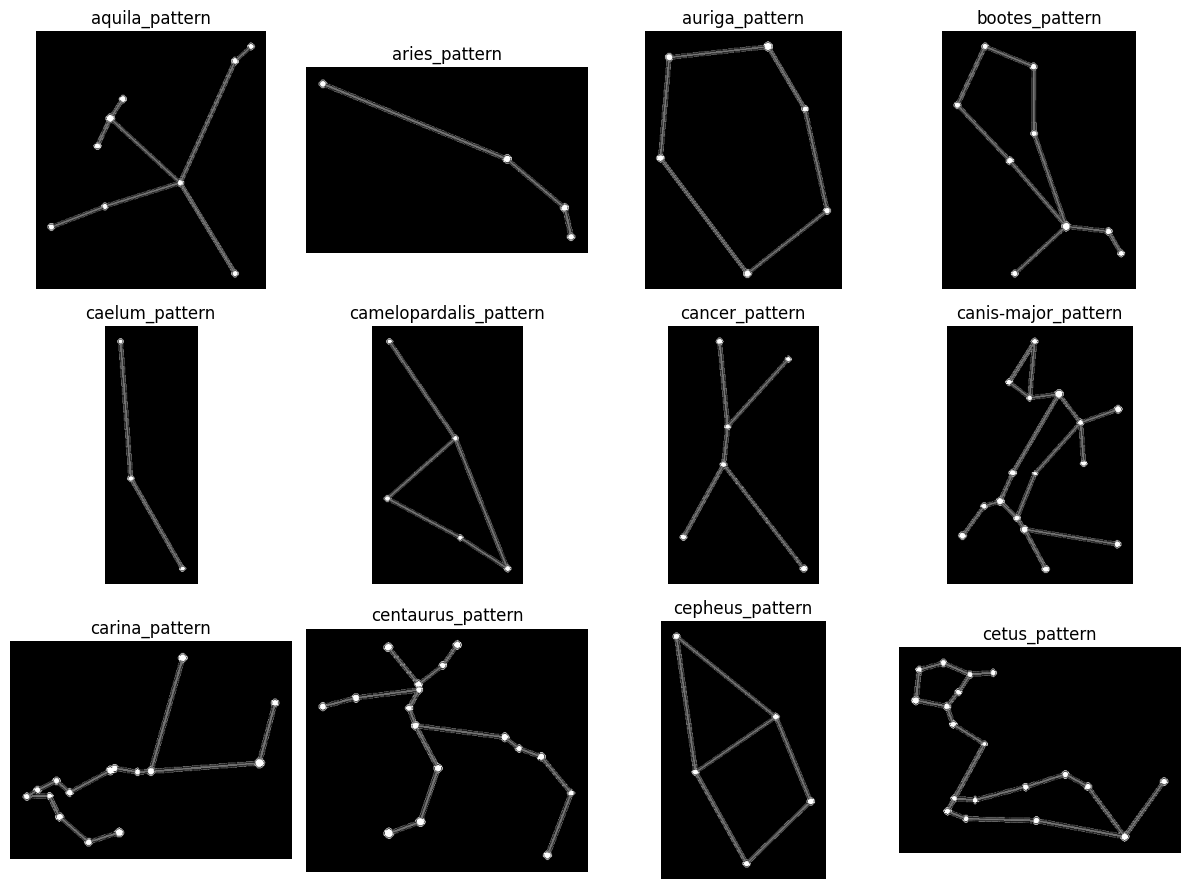

In [ ]:
fig, axes = plt.subplots(
    3, 4,
    figsize=(12, 9)
)

for ax, path in zip(
    axes.ravel(),
    pattern_paths[:12]
):
    img = np.array(
        Image.open(path).convert("L")
    )

    ax.imshow(
        img,
        cmap="gray"
    )

    ax.set_title(path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

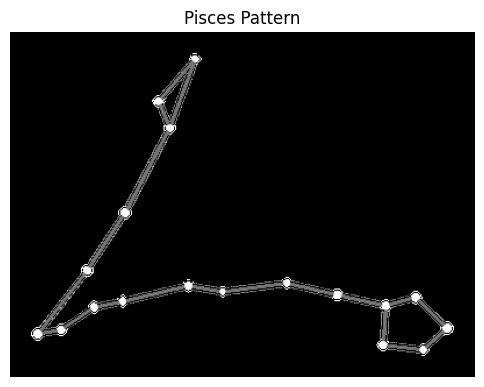

Shape: (297, 400)
Min: 0
Max: 255


In [ ]:
pisces_pattern_path = DATA_ROOT / "patterns" / "pisces_pattern.png"

pisces_pattern = np.array(
    Image.open(pisces_pattern_path).convert("L")
)

plt.figure(figsize=(6, 6))
plt.imshow(pisces_pattern, cmap="gray")
plt.title("Pisces Pattern")
plt.axis("off")
plt.show()

print("Shape:", pisces_pattern.shape)
print("Min:", pisces_pattern.min())
print("Max:", pisces_pattern.max())

In [ ]:

node_mask = (
    pisces_pattern > 220
).astype(np.uint8)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    node_mask,
    connectivity=8
)

nodes = []

for i in range(1, num_labels):

    area = stats[
        i,
        cv2.CC_STAT_AREA
    ]
    if area >= 3:
        x, y = centroids[i]
        nodes.append((x, y, area))

print("Detected nodes:", len(nodes))

Detected nodes: 21


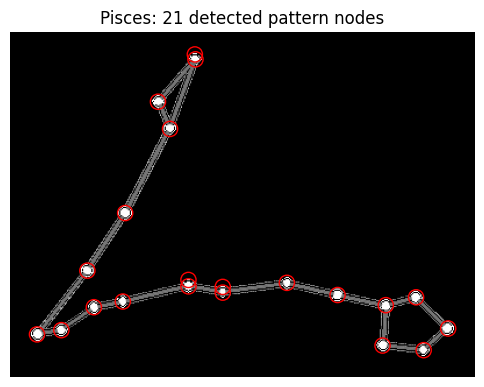

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(
    pisces_pattern,
    cmap="gray"
)

for x, y, area in nodes:
    plt.scatter(
        x,
        y,
        s=120,
        facecolors="none",
        edgecolors="red"
    )

plt.title(
    f"Pisces: {len(nodes)} detected pattern nodes"
)

plt.axis("off")
plt.show()

In [ ]:

pattern_pts = np.array(
    [[x, y] for x, y, area in nodes],
    dtype=np.float32
)

figure_pts = []

for patch_name, info in parsed_truth.items():
    if info["present"] and info["m"] == 1:
        figure_pts.append([
            info["x"],
            info["y"]
        ])

figure_pts = np.array(
    figure_pts,
    dtype=np.float32
)

print("Pattern nodes:", len(pattern_pts))
print("Known Pisces figure stars:", len(figure_pts))

Pattern nodes: 21
Known Pisces figure stars: 10


In [ ]:
rng = np.random.default_rng(42)

best_count = 0
best_error = np.inf
best_M = None

iterations = 50000
tolerance = 40

for _ in range(iterations):

    # Pick 3 pattern nodes
    src_ids = rng.choice(
        len(pattern_pts),
        3,
        replace=False
    )

    # Pick 3 known sky figure stars
    dst_ids = rng.choice(
        len(figure_pts),
        3,
        replace=False
    )

    src = pattern_pts[src_ids]
    dst = figure_pts[dst_ids]

    # Random correspondence between the triangles
    dst = dst[
        rng.permutation(3)
    ]

    # Skip nearly degenerate pattern triangles
    area = abs(
        np.cross(
            src[1] - src[0],
            src[2] - src[0]
        )
    )

    if area < 20:
        continue

    M = cv2.getAffineTransform(
        src.astype(np.float32),
        dst.astype(np.float32)
    )

    transformed = cv2.transform(
        pattern_pts[None, :, :],
        M
    )[0]

    # For each known figure star:
    # how close is the nearest transformed pattern node?
    distances = np.sqrt(
        (
            (
                figure_pts[:, None, :]
                -
                transformed[None, :, :]
            ) ** 2
        ).sum(axis=2)
    )

    nearest = distances.min(axis=1)

    count = np.sum(
        nearest <= tolerance
    )

    mean_error = nearest[
        nearest <= tolerance
    ].mean() if count > 0 else np.inf

    if (
        count > best_count
        or
        (
            count == best_count
            and mean_error < best_error
        )
    ):
        best_count = count
        best_error = mean_error
        best_M = M.copy()

print("Matched figure stars:", best_count, "/ 10")
print("Mean inlier error:", best_error)

/tmp/ipykernel_3294/111662855.py:36: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  np.cross(


Matched figure stars: 8 / 10
Mean inlier error: 7.881619


In [ ]:
from scipy.optimize import linear_sum_assignment

# Transform all 21 Pisces pattern nodes using our best affine transform
transformed = cv2.transform(
    pattern_pts[None, :, :],
    best_M
)[0]

# Distance from every known figure star
# to every transformed pattern node
D = np.sqrt(
    (
        (
            figure_pts[:, None, :]
            -
            transformed[None, :, :]
        ) ** 2
    ).sum(axis=2)
)

# Force unique star-to-node assignments
figure_ids, pattern_ids = linear_sum_assignment(D)

assigned_distances = D[
    figure_ids,
    pattern_ids
]

tolerance = 40

good = assigned_distances <= tolerance

print(
    "Unique matched figure stars:",
    good.sum(),
    "/",
    len(figure_pts)
)

print(
    "Mean error of unique matches:",
    assigned_distances[good].mean()
)

print(
    "Assigned distances:",
    np.round(assigned_distances, 2)
)

Unique matched figure stars: 8 / 10
Mean error of unique matches: 7.881619
Assigned distances: [79.1  13.42  9.39 40.31 21.58  1.5   0.    0.   17.16  0.  ]


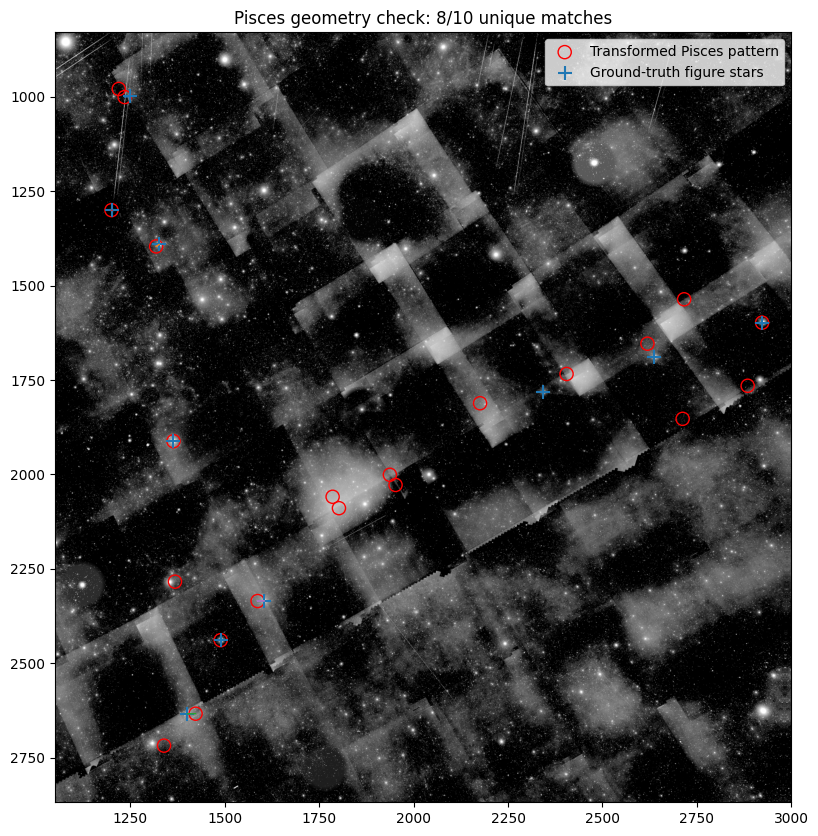

In [ ]:
# Transform all Pisces pattern nodes into scene coordinates
transformed = cv2.transform(
    pattern_pts[None, :, :],
    best_M
)[0]

# Distance from every true figure star
# to every transformed pattern node
D = np.linalg.norm(
    figure_pts[:, None, :]
    - transformed[None, :, :],
    axis=2
)

figure_ids, pattern_ids = linear_sum_assignment(D)

assigned_distances = D[
    figure_ids,
    pattern_ids
]

good = assigned_distances <= 40


plt.figure(figsize=(10, 10))

plt.imshow(scene, cmap="gray")

# All 21 transformed Pisces nodes
plt.scatter(
    transformed[:, 0],
    transformed[:, 1],
    s=90,
    facecolors="none",
    edgecolors="red",
    label="Transformed Pisces pattern"
)

# 10 true m=1 stars
plt.scatter(
    figure_pts[:, 0],
    figure_pts[:, 1],
    s=90,
    marker="+",
    label="Ground-truth figure stars"
)

# Draw lines between successful unique matches
for fi, pi, is_good in zip(
    figure_ids,
    pattern_ids,
    good
):
    if is_good:
        plt.plot(
            [
                figure_pts[fi, 0],
                transformed[pi, 0]
            ],
            [
                figure_pts[fi, 1],
                transformed[pi, 1]
            ],
            linewidth=1
        )

plt.title(
    f"Pisces geometry check: {good.sum()}/10 unique matches"
)

plt.legend()

# Zoom to relevant area
all_x = np.concatenate([
    transformed[:, 0],
    figure_pts[:, 0]
])

all_y = np.concatenate([
    transformed[:, 1],
    figure_pts[:, 1]
])

margin = 150

plt.xlim(
    max(0, all_x.min() - margin),
    min(scene.shape[1], all_x.max() + margin)
)

plt.ylim(
    min(scene.shape[0], all_y.max() + margin),
    max(0, all_y.min() - margin)
)

plt.show()

In [ ]:
def extract_pattern_nodes(path, threshold=220, min_area=3):

    img = np.array(
        Image.open(path).convert("L")
    )

    mask = (img > threshold).astype(np.uint8)

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )
    )

    pts = []

    for i in range(1, num_labels):

        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_area:
            x, y = centroids[i]
            pts.append([x, y])

    return np.array(
        pts,
        dtype=np.float32
    )

In [ ]:
all_patterns = {}

for path in pattern_paths:

    name = path.stem.replace(
        "_pattern",
        ""
    )

    all_patterns[name] = (
        extract_pattern_nodes(path)
    )

print("Patterns loaded:", len(all_patterns))

Patterns loaded: 48


In [ ]:
def fit_pattern_to_points(
    pattern_pts,
    sky_pts,
    iterations=10000,
    tolerance=40,
    seed=42
):

    if len(pattern_pts) < 3:
        return None

    rng = np.random.default_rng(seed)

    best_count = 0
    best_mean_error = np.inf
    best_M = None

    for _ in range(iterations):

        src_ids = rng.choice(
            len(pattern_pts),
            3,
            replace=False
        )

        dst_ids = rng.choice(
            len(sky_pts),
            3,
            replace=False
        )

        src = pattern_pts[src_ids]

        dst = sky_pts[
            dst_ids[
                rng.permutation(3)
            ]
        ]

        # Triangle area
        v1 = src[1] - src[0]
        v2 = src[2] - src[0]

        area = abs(
            v1[0] * v2[1]
            -
            v1[1] * v2[0]
        )

        if area < 20:
            continue

        M = cv2.getAffineTransform(
            src.astype(np.float32),
            dst.astype(np.float32)
        )

        transformed = cv2.transform(
            pattern_pts[None, :, :],
            M
        )[0]

        D = np.linalg.norm(
            sky_pts[:, None, :]
            -
            transformed[None, :, :],
            axis=2
        )

        # Cheap score during RANSAC
        nearest = D.min(axis=1)

        count = np.sum(
            nearest <= tolerance
        )

        mean_error = (
            nearest[nearest <= tolerance].mean()
            if count > 0
            else np.inf
        )

        if (
            count > best_count
            or
            (
                count == best_count
                and mean_error < best_mean_error
            )
        ):
            best_count = count
            best_mean_error = mean_error
            best_M = M.copy()

    if best_M is None:
        return None

    # Final UNIQUE assignment
    transformed = cv2.transform(
        pattern_pts[None, :, :],
        best_M
    )[0]

    D = np.linalg.norm(
        sky_pts[:, None, :]
        -
        transformed[None, :, :],
        axis=2
    )

    sky_ids, pattern_ids = (
        linear_sum_assignment(D)
    )

    assigned = D[
        sky_ids,
        pattern_ids
    ]

    good = assigned <= tolerance

    return {
        "matches": int(good.sum()),
        "mean_error": float(
            assigned[good].mean()
            if good.any()
            else np.inf
        ),
        "M": best_M
    }

In [ ]:
pattern_results = []

for name, pts in all_patterns.items():

    result = fit_pattern_to_points(
        pts,
        figure_pts,
        iterations=10000,
        tolerance=40
    )

    if result is None:
        continue

    pattern_results.append({
        "constellation": name,
        "nodes": len(pts),
        "matches": result["matches"],
        "mean_error": result["mean_error"]
    })


pattern_rank_df = pd.DataFrame(
    pattern_results
)

pattern_rank_df = pattern_rank_df.sort_values(
    ["matches", "mean_error"],
    ascending=[False, True]
)

display(
    pattern_rank_df.head(15)
)

,constellation,nodes,matches,mean_error
34,pisces,21,7,4.537119
19,eridanus,29,6,10.637876
7,canis-major,16,6,18.183638
9,centaurus,17,5,2.970577
44,ursa-major,17,5,5.644574
8,carina,15,5,5.728619
42,taurus,11,5,5.975738
31,orion,23,5,6.498248
37,sagittarius,23,5,7.498111
25,lupus,13,5,8.035109


In [ ]:
def get_figure_points(scene_name, train_gt):
    row = train_gt[
        train_gt["Id"] == scene_name
    ].iloc[0]

    n = int(row["n_patches"])

    pts = []

    for i in range(1, n + 1):

        value = row[f"patch_{i:02d}"]

        info = parse_truth(value)

        if info["present"] and info["m"] == 1:
            pts.append([
                info["x"],
                info["y"]
            ])

    return np.array(
        pts,
        dtype=np.float32
    )

In [ ]:
for scene_name in ["pisces", "scorpius", "taurus"]:

    sky_pts = get_figure_points(
        scene_name,
        train_gt
    )

    results = []

    for name, pts in all_patterns.items():

        result = fit_pattern_to_points(
            pts,
            sky_pts,
            iterations=15000,
            tolerance=40
        )

        if result is None:
            continue

        results.append({
            "constellation": name,
            "matches": result["matches"],
            "mean_error": result["mean_error"]
        })

    df = pd.DataFrame(results).sort_values(
        ["matches", "mean_error"],
        ascending=[False, True]
    )

    print("\n====================")
    print(scene_name.upper())
    print("====================")

    display(df.head(5))


PISCES


,constellation,matches,mean_error
34,pisces,8,11.051392
37,sagittarius,6,9.645942
19,eridanus,6,10.637876
7,canis-major,6,17.999910
31,orion,5,2.090985



SCORPIUS


,constellation,matches,mean_error
38,scorpius,10,9.848186
31,orion,6,7.070302
37,sagittarius,6,7.133050
9,centaurus,6,10.276010
11,cetus,6,10.572534



TAURUS


,constellation,matches,mean_error
42,taurus,6,7.276180
19,eridanus,6,15.900975
31,orion,5,5.568608
37,sagittarius,5,6.814588
9,centaurus,5,7.468981


In [ ]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from scipy.optimize import linear_sum_assignment

DATA_ROOT = Path("/content/participant")

train_gt = pd.read_csv(
    DATA_ROOT / "train_ground_truth.csv"
)

def parse_truth(value):
    if str(value).strip() == "-1":
        return {
            "present": False,
            "x": None,
            "y": None,
            "m": None
        }

    x, y, m = ast.literal_eval(str(value))

    return {
        "present": True,
        "x": float(x),
        "y": float(y),
        "m": int(m)
    }


def load_train_scene(scene_name):

    scene_dir = DATA_ROOT / "train" / scene_name

    scene = np.array(
        Image.open(
            scene_dir / f"{scene_name}_image.png"
        ).convert("L")
    )

    patch_dir = scene_dir / "patches"

    patch_paths = sorted(
        patch_dir.glob("*.png")
    )

    row = train_gt[
        train_gt["Id"] == scene_name
    ].iloc[0]

    truth = {}

    for i in range(
        1,
        int(row["n_patches"]) + 1
    ):
        name = f"patch_{i:02d}"

        truth[name] = parse_truth(
            row[name]
        )

    return {
        "scene": scene,
        "patch_dir": patch_dir,
        "patch_paths": patch_paths,
        "truth": truth
    }


train_scenes = {
    name: load_train_scene(name)
    for name in [
        "pisces",
        "scorpius",
        "taurus"
    ]
}

for name, data in train_scenes.items():

    n_present = sum(
        info["present"]
        for info in data["truth"].values()
    )

    n_figure = sum(
        info["present"]
        and info["m"] == 1
        for info in data["truth"].values()
    )

    print(
        name,
        "| patches:", len(data["truth"]),
        "| present:", n_present,
        "| figure:", n_figure
    )

pisces | patches: 41 | present: 27 | figure: 10
scorpius | patches: 41 | present: 26 | figure: 10
taurus | patches: 34 | present: 18 | figure: 6


In [ ]:
# ============================================================
# Q5 FINAL PIPELINE — CELL 2
# Pattern extraction + scene indexing + patch hypotheses
# ============================================================

# -----------------------------
# Patch transformation
# -----------------------------
def transform_patch(patch, angle, scale):
    h, w = patch.shape

    center = (
        (w - 1) / 2,
        (h - 1) / 2
    )

    M = cv2.getRotationMatrix2D(
        center,
        angle,
        scale
    )

    return cv2.warpAffine(
        patch,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )


# -----------------------------
# Normalize many flattened crops
# -----------------------------
def normalize_rows(x):
    x = x.astype(np.float32)

    x -= x.mean(
        axis=1,
        keepdims=True
    )

    x /= (
        x.std(
            axis=1,
            keepdims=True
        ) + 1e-8
    )

    return x


# -----------------------------
# Extract constellation nodes
# from pattern schematic
# -----------------------------
def extract_pattern_nodes(
    path,
    threshold=220,
    min_area=3
):
    img = np.array(
        Image.open(path).convert("L")
    )

    mask = (
        img > threshold
    ).astype(np.uint8)

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )
    )

    pts = []

    for i in range(1, num_labels):

        area = stats[
            i,
            cv2.CC_STAT_AREA
        ]

        if area >= min_area:
            x, y = centroids[i]
            pts.append([x, y])

    return np.array(
        pts,
        dtype=np.float32
    )


# Load all 48 constellation patterns
all_patterns = {}

for path in sorted(
    (DATA_ROOT / "patterns").glob("*.png")
):
    name = path.stem.replace(
        "_pattern",
        ""
    )

    all_patterns[name] = (
        extract_pattern_nodes(path)
    )


# -----------------------------
# Build high-recall candidate
# star centers for one scene
# -----------------------------
def build_scene_index(
    scene,
    threshold=3.5,
    nms_size=21
):
    gray = scene.astype(np.float32)

    sigmas = [
        1.5,
        3.0,
        6.0,
        10.0
    ]

    multi_score = np.full(
        gray.shape,
        -np.inf,
        dtype=np.float32
    )

    # Multi-scale star response
    for sigma in sigmas:

        background = cv2.GaussianBlur(
            gray,
            (0, 0),
            sigmaX=sigma
        )

        response = gray - background

        med = np.median(response)

        mad = np.median(
            np.abs(response - med)
        )

        robust_std = (
            1.4826 * mad + 1e-8
        )

        z = (
            response - med
        ) / robust_std

        multi_score = np.maximum(
            multi_score,
            z
        )

    # Non-maximum suppression
    kernel = np.ones(
        (nms_size, nms_size),
        dtype=np.uint8
    )

    local_max = cv2.dilate(
        multi_score,
        kernel
    )

    peaks = (
        (multi_score == local_max)
        &
        (multi_score >= threshold)
    )

    ys, xs = np.nonzero(peaks)

    candidates = np.column_stack(
        [xs, ys]
    )

    H, W = scene.shape

    # Need room for a 32x32 crop
    valid = (
        (candidates[:, 0] >= 16)
        &
        (candidates[:, 0] < W - 16)
        &
        (candidates[:, 1] >= 16)
        &
        (candidates[:, 1] < H - 16)
    )

    candidates = candidates[valid]

    # Extract all candidate crops
    crops = np.stack([
        scene[
            y-16:y+16,
            x-16:x+16
        ]
        for x, y in candidates
    ])

    vectors = normalize_rows(
        crops.reshape(
            len(crops),
            -1
        )
    )

    return {
        "candidates": candidates,
        "vectors": vectors
    }


# -----------------------------
# Generate several plausible
# locations for one query patch
# -----------------------------
def get_query_hypotheses(
    query,
    scene_index,
    top_k=200
):
    candidates = (
        scene_index["candidates"]
    )

    candidate_vectors = (
        scene_index["vectors"]
    )

    transforms = []
    params = []

    # Coarse rotation + scale grid
    for scale in [
        0.9,
        1.0,
        1.1
    ]:

        for angle in range(
            0,
            360,
            20
        ):

            t = transform_patch(
                query,
                angle,
                scale
            )

            transforms.append(
                t.ravel()
            )

            params.append(
                (angle, scale)
            )

    transforms = normalize_rows(
        np.stack(transforms)
    )

    scores = (
        transforms
        @ candidate_vectors.T
    ) / (32 * 32)

    best_transform = np.argmax(
        scores,
        axis=0
    )

    best_scores = np.max(
        scores,
        axis=0
    )

    top_ids = np.argsort(
        best_scores
    )[::-1][:top_k]

    hypotheses = []

    for rank, idx in enumerate(
        top_ids,
        start=1
    ):
        angle, scale = params[
            best_transform[idx]
        ]

        x, y = candidates[idx]

        hypotheses.append({
            "x": int(x),
            "y": int(y),
            "score": float(
                best_scores[idx]
            ),
            "rank": rank,
            "angle": angle,
            "scale": scale
        })

    return hypotheses


print(
    "Pattern database:",
    len(all_patterns),
    "constellations"
)

print(
    "Final matching helpers ready."
)

Pattern database: 48 constellations
Final matching helpers ready.


In [ ]:
# ============================================================
# Q5 FINAL PIPELINE — CELL 3
# Build scene indexes + local hypotheses for training data
# ============================================================

train_indexes = {}
train_hypotheses = {}

for scene_name, data in train_scenes.items():

    print(f"\nBuilding index for {scene_name}...")

    scene_index = build_scene_index(
        data["scene"]
    )

    train_indexes[scene_name] = scene_index

    print(
        "Candidate locations:",
        len(scene_index["candidates"])
    )

    scene_hypotheses = {}

    patch_names = sorted(
        data["truth"].keys()
    )

    for j, patch_name in enumerate(
        patch_names,
        start=1
    ):

        query = np.array(
            Image.open(
                data["patch_dir"] /
                f"{patch_name}.png"
            ).convert("L")
        )

        hypotheses = get_query_hypotheses(
            query,
            scene_index,
            top_k=200
        )

        scene_hypotheses[
            patch_name
        ] = hypotheses

        if (
            j % 10 == 0
            or j == len(patch_names)
        ):
            print(
                f"  {j}/{len(patch_names)} patches done"
            )

    train_hypotheses[
        scene_name
    ] = scene_hypotheses


print("\nTraining hypotheses ready.")


Building index for pisces...
Candidate locations: 19172
  10/41 patches done
  20/41 patches done
  30/41 patches done
  40/41 patches done
  41/41 patches done

Building index for scorpius...
Candidate locations: 18448
  10/41 patches done
  20/41 patches done
  30/41 patches done
  40/41 patches done
  41/41 patches done

Building index for taurus...
Candidate locations: 17699
  10/34 patches done
  20/34 patches done
  30/34 patches done
  34/34 patches done

Training hypotheses ready.


In [ ]:
# ============================================================
# Q5 FINAL PIPELINE — CELL 4
# Build supervised candidate-training table
# ============================================================

candidate_rows = []

for scene_name, data in train_scenes.items():

    print(f"Building features for {scene_name}...")

    candidates = train_indexes[
        scene_name
    ]["candidates"]

    candidate_vectors = train_indexes[
        scene_name
    ]["vectors"]

    # Candidate coordinate -> row in candidate_vectors
    coord_to_idx = {
        (int(x), int(y)): i
        for i, (x, y) in enumerate(candidates)
    }

    for patch_name, truth in data["truth"].items():

        # Load query
        query = np.array(
            Image.open(
                data["patch_dir"] /
                f"{patch_name}.png"
            ).convert("L")
        )

        # ----------------------------------------------------
        # Recreate all 54 rotation/scale versions
        # ----------------------------------------------------

        transforms = []

        for scale in [0.9, 1.0, 1.1]:

            for angle in range(0, 360, 20):

                t = transform_patch(
                    query,
                    angle,
                    scale
                )

                transforms.append(
                    t.ravel()
                )

        transforms = normalize_rows(
            np.stack(transforms)
        )

        # Only use cached top 100 locations
        hyps = train_hypotheses[
            scene_name
        ][patch_name][:100]

        indices = [
            coord_to_idx[
                (h["x"], h["y"])
            ]
            for h in hyps
        ]

        local_vectors = candidate_vectors[
            indices
        ]

        # 54 transforms x 100 possible locations
        S = (
            transforms
            @ local_vectors.T
        ) / (32 * 32)

        sorted_S = np.sort(
            S,
            axis=0
        )

        best = sorted_S[-1]
        second = sorted_S[-2]

        mean_score = S.mean(axis=0)
        std_score = S.std(axis=0)

        top5_transform_mean = (
            sorted_S[-5:].mean(axis=0)
        )

        patch_best_score = best.max()

        # ----------------------------------------------------
        # One training row per candidate location
        # ----------------------------------------------------

        for j, h in enumerate(hyps):

            if truth["present"]:

                distance = np.hypot(
                    h["x"] - truth["x"],
                    h["y"] - truth["y"]
                )

                good = int(
                    distance <= 12
                )

            else:
                distance = np.nan
                good = 0

            candidate_rows.append({
                "scene": scene_name,
                "patch": patch_name,

                # Ground truth
                "truth_present":
                    int(truth["present"]),

                "good_location":
                    good,

                "distance":
                    distance,

                # Candidate features
                "score":
                    float(best[j]),

                "rank":
                    h["rank"],

                "score_below_best":
                    float(
                        patch_best_score
                        - best[j]
                    ),

                # Does one particular transform
                # clearly fit better than the others?
                "transform_margin":
                    float(
                        best[j]
                        - second[j]
                    ),

                "transform_std":
                    float(
                        std_score[j]
                    ),

                "peak_over_mean":
                    float(
                        best[j]
                        - mean_score[j]
                    ),

                "peak_over_top5":
                    float(
                        best[j]
                        - top5_transform_mean[j]
                    ),

                "scale_offset":
                    abs(
                        float(h["scale"])
                        - 1.0
                    )
            })


candidate_df = pd.DataFrame(
    candidate_rows
)

print("\nCandidate table ready.")
print("Rows:", len(candidate_df))
print(
    "True-location candidates:",
    candidate_df[
        "good_location"
    ].sum()
)
print(
    "Training patches:",
    candidate_df[
        ["scene", "patch"]
    ].drop_duplicates().shape[0]
)

display(
    candidate_df.head()
)

Building features for pisces...
Building features for scorpius...
Building features for taurus...

Candidate table ready.
Rows: 11600
True-location candidates: 47
Training patches: 116


,scene,patch,truth_present,good_location,distance,score,rank,score_below_best,transform_margin,transform_std,peak_over_mean,peak_over_top5,scale_offset
0,pisces,patch_01,1,0,815.434240,0.853080,1,0.000000,0.017819,0.467578,0.826941,0.048590,0.1
1,pisces,patch_01,1,0,1376.688781,0.851178,2,0.001902,0.009808,0.476845,0.824312,0.025781,0.1
2,pisces,patch_01,1,0,1238.684786,0.841344,3,0.011736,0.048566,0.488917,0.836417,0.049381,0.1
3,pisces,patch_01,1,0,845.591509,0.837734,4,0.015346,0.003988,0.467522,0.814945,0.029314,0.0
4,pisces,patch_01,1,0,1363.742644,0.836769,5,0.016311,0.023465,0.478331,0.822141,0.033736,0.1


In [ ]:
# ============================================================
# Q5 FINAL PIPELINE — CELL 5
# Leave-one-scene-out candidate reranking
# ============================================================

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

feature_cols = [
    "score",
    "rank",
    "score_below_best",
    "transform_margin",
    "transform_std",
    "peak_over_mean",
    "peak_over_top5",
    "scale_offset"
]

rerank_results = {}

for test_scene in [
    "pisces",
    "scorpius",
    "taurus"
]:

    train_part = candidate_df[
        candidate_df["scene"] != test_scene
    ].copy()

    test_part = candidate_df[
        candidate_df["scene"] == test_scene
    ].copy()

    X_train = train_part[feature_cols]
    y_train = train_part["good_location"]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )

    model.fit(
        X_train,
        y_train
    )

    # Probability that each candidate is the true location
    test_part["rerank_score"] = (
        model.predict_proba(
            test_part[feature_cols]
        )[:, 1]
    )

    rerank_results[test_scene] = (
        test_part
    )

    old_ranks = []
    new_ranks = []

    # Only evaluate patches that are truly present
    truth = train_scenes[
        test_scene
    ]["truth"]

    for patch_name, info in truth.items():

        if not info["present"]:
            continue

        patch_df = test_part[
            test_part["patch"] == patch_name
        ].copy()

        # Is the true location even in our top-100?
        good_rows = patch_df[
            patch_df["good_location"] == 1
        ]

        if len(good_rows) == 0:
            old_ranks.append(None)
            new_ranks.append(None)
            continue

        # Original correlation rank
        old_rank = int(
            good_rows["rank"].min()
        )

        # New learned rank
        ranked = patch_df.sort_values(
            "rerank_score",
            ascending=False
        ).reset_index(drop=True)

        new_rank = int(
            ranked.index[
                ranked["good_location"] == 1
            ][0]
        ) + 1

        old_ranks.append(old_rank)
        new_ranks.append(new_rank)

    print(
        "\n===================="
    )
    print(test_scene.upper())
    print("====================")

    for k in [1, 5, 10, 20, 50, 100]:

        old_n = sum(
            r is not None and r <= k
            for r in old_ranks
        )

        new_n = sum(
            r is not None and r <= k
            for r in new_ranks
        )

        print(
            f"Top {k:3d}: "
            f"old {old_n:2d}  ->  "
            f"reranked {new_n:2d}"
        )

    print(
        "Present patches:",
        len(old_ranks)
    )

    print(
        "True location available in top 100:",
        sum(r is not None for r in new_ranks)
    )


PISCES
Top   1: old  4  ->  reranked  2
Top   5: old 11  ->  reranked  4
Top  10: old 12  ->  reranked  6
Top  20: old 14  ->  reranked  9
Top  50: old 17  ->  reranked 17
Top 100: old 19  ->  reranked 19
Present patches: 27
True location available in top 100: 19

SCORPIUS
Top   1: old  1  ->  reranked  1
Top   5: old  4  ->  reranked  2
Top  10: old  6  ->  reranked  6
Top  20: old  9  ->  reranked  8
Top  50: old 13  ->  reranked 14
Top 100: old 16  ->  reranked 16
Present patches: 26
True location available in top 100: 16

TAURUS
Top   1: old  1  ->  reranked  0
Top   5: old  3  ->  reranked  1
Top  10: old  3  ->  reranked  4
Top  20: old  8  ->  reranked  7
Top  50: old 10  ->  reranked 10
Top 100: old 11  ->  reranked 11
Present patches: 18
True location available in top 100: 11


### Final Step 1: Train the full model
We will use all available training data to train the Logistic Regression model.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Train final model on ALL training data
final_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )
)

final_model.fit(
    candidate_df[feature_cols],
    candidate_df["good_location"]
)

print("Final model trained on all 3 train scenes.")

Final model trained on all 3 train scenes.


### Final Step 2: Inference Function
This function takes a scene, finds the patches using your model, and then matches the detected points to the 48 constellation patterns to identify the constellation and figure stars.

In [ ]:
def predict_scene(scene_id, patch_dir, scene_img, model, patterns, threshold=0.6):
    # 1. Build Scene Index
    scene_index = build_scene_index(scene_img)
    candidates = scene_index["candidates"]
    candidate_vectors = scene_index["vectors"]
    coord_to_idx = {(int(x), int(y)): i for i, (x, y) in enumerate(candidates)}

    patch_paths = sorted(patch_dir.glob("*.png"))
    results = {}

    present_pts = []
    patch_meta = {}

    # 2. Predict each patch
    for path in patch_paths:
        patch_name = path.stem
        query = np.array(Image.open(path).convert("L"))

        # Coarse hypotheses
        hyps = get_query_hypotheses(query, scene_index, top_k=100)

        # Feature extraction
        transforms = []
        for scale in [0.9, 1.0, 1.1]:
            for angle in range(0, 360, 20):
                t = transform_patch(query, angle, scale)
                transforms.append(t.ravel())
        transforms = normalize_rows(np.stack(transforms))

        indices = [coord_to_idx[(h["x"], h["y"])] for h in hyps]
        local_vectors = candidate_vectors[indices]

        S = (transforms @ local_vectors.T) / (32 * 32)
        sorted_S = np.sort(S, axis=0)
        best = sorted_S[-1]
        second = sorted_S[-2]
        mean_score = S.mean(axis=0)
        std_score = S.std(axis=0)
        top5_mean = sorted_S[-5:].mean(axis=0)
        patch_best_score = best.max()

        features = []
        for j, h in enumerate(hyps):
            features.append([
                float(best[j]), h["rank"], float(patch_best_score - best[j]),
                float(best[j] - second[j]), float(std_score[j]),
                float(best[j] - mean_score[j]), float(best[j] - top5_mean[j]),
                abs(float(h["scale"]) - 1.0)
            ])

        features_df = pd.DataFrame(features, columns=feature_cols)
        probs = model.predict_proba(features_df)[:, 1]

        best_idx = np.argmax(probs)
        best_prob = probs[best_idx]

        if best_prob > threshold:
            best_hyp = hyps[best_idx]
            results[patch_name] = {"present": True, "x": best_hyp["x"], "y": best_hyp["y"]}
            present_pts.append([best_hyp["x"], best_hyp["y"]])
            patch_meta[patch_name] = len(present_pts) - 1
        else:
            results[patch_name] = {"present": False, "x": -1, "y": -1}

    # 3. Constellation Matching
    present_pts_arr = np.array(present_pts, dtype=np.float32)
    best_constellation = "unknown"
    best_pattern_matches = -1
    best_pattern_error = np.inf
    best_assignment_mask = np.zeros(len(present_pts_arr), dtype=bool)

    if len(present_pts_arr) >= 3:
        for name, pts in patterns.items():
            res = fit_pattern_to_points(pts, present_pts_arr, iterations=5000, tolerance=40)
            if res is None: continue

            if res["matches"] > best_pattern_matches or (res["matches"] == best_pattern_matches and res["mean_error"] < best_pattern_error):
                best_pattern_matches = res["matches"]
                best_pattern_error = res["mean_error"]
                best_constellation = name

                # Get boolean mask of mapped stars
                transformed = cv2.transform(pts[None, :, :], res["M"])[0]
                D = np.linalg.norm(present_pts_arr[:, None, :] - transformed[None, :, :], axis=2)
                sky_ids, pattern_ids = linear_sum_assignment(D)
                good = D[sky_ids, pattern_ids] <= 40

                mask = np.zeros(len(present_pts_arr), dtype=bool)
                mask[sky_ids[good]] = True
                best_assignment_mask = mask

    # 4. Assign m=1/0 values
    for patch_name, r in results.items():
        if r["present"]:
            idx = patch_meta[patch_name]
            r["m"] = 1 if best_assignment_mask[idx] else 0
        else:
            r["m"] = -1

    return results, best_constellation

### Final Step 3: Generate Submission
Process all validation scenes and output `submission.csv`.

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image

sample_sub = pd.read_csv(DATA_ROOT / "sample_submission.csv")
submission_rows = []

print("Starting validation inference. This will take a few minutes...")

for idx, row in sample_sub.iterrows():
    scene_id = row["Id"]
    print(f"Processing {scene_id}...")

    scene_dir = DATA_ROOT / "validation" / scene_id
    scene_img_path = scene_dir / f"{scene_id}_image.png"
    patch_dir = scene_dir / "patches"

    if scene_img_path.exists():
        scene_img = np.array(Image.open(scene_img_path).convert("L"))
        results, constellation = predict_scene(scene_id, patch_dir, scene_img, final_model, all_patterns)
    else:
        results = {}
        constellation = "unknown"

    # Format output row
    sub_row = {"Id": scene_id, "n_patches": row["n_patches"]}
    for i in range(1, 88):
        col = f"patch_{i:02d}"
        if i <= row["n_patches"]:
            if col in results and results[col]["present"]:
                r = results[col]
                sub_row[col] = f"({r['x']}, {r['y']}, {r['m']})"
            else:
                sub_row[col] = "-1"
        else:
            sub_row[col] = "-1"

    sub_row["constellation"] = constellation
    submission_rows.append(sub_row)

submission_df = pd.DataFrame(submission_rows)
submission_df.to_csv("submission.csv", index=False)
print("Saved submission.csv! You can now download it and submit to Kaggle.")
display(submission_df.head())

Starting validation inference. This will take a few minutes...
Processing constellation_01...
Processing constellation_02...
Processing constellation_03...
Processing constellation_04...
Processing constellation_05...
Processing constellation_06...
Processing constellation_07...
Processing constellation_08...
Processing constellation_10...
Processing constellation_11...
Processing constellation_12...
Processing constellation_13...
Processing constellation_14...
Processing constellation_15...
Processing constellation_16...
Processing constellation_17...
Saved submission.csv! You can now download it and submit to Kaggle.


,Id,n_patches,patch_01,patch_02,patch_03,patch_04,patch_05,patch_06,patch_07,patch_08,...,patch_79,patch_80,patch_81,patch_82,patch_83,patch_84,patch_85,patch_86,patch_87,constellation
0,constellation_01,23,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,carina
1,constellation_02,24,-1,"(1360, 1210, 1)",-1,-1,-1,"(2443, 2575, 0)","(2499, 508, 1)","(705, 2025, 1)",...,-1,-1,-1,-1,-1,-1,-1,-1,-1,eridanus
2,constellation_03,31,"(230, 1865, 0)","(801, 1911, 1)","(2951, 42, 0)","(973, 2761, 0)","(292, 2684, 0)","(22, 2552, 1)",-1,"(1141, 2266, 1)",...,-1,-1,-1,-1,-1,-1,-1,-1,-1,pisces
3,constellation_04,54,-1,-1,-1,-1,-1,"(2288, 1886, 0)",-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,carina
4,constellation_05,87,-1,-1,-1,"(2196, 2458, 1)",-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,"(2788, 1562, 1)",eridanus


### Submission Diagnostics
Let's analyze the generated `submission.csv` to ensure the formatting is correct and the predictions look reasonable (e.g., not overwhelmingly 'unknown' and finding a plausible number of patches).

In [ ]:
import pandas as pd

sub_df = pd.read_csv('submission.csv')

print(f"Total submission rows: {len(sub_df)}\n")

print("=== Constellation Predictions ===")
print(sub_df['constellation'].value_counts())
print("\n")

print("=== Patch Prediction Stats per Scene ===")
for idx, row in sub_df.iterrows():
    n_patches = row['n_patches']
    present_count = 0
    absent_count = 0

    for i in range(1, n_patches + 1):
        val = row[f'patch_{i:02d}']
        if str(val).strip() == '-1':
            absent_count += 1
        else:
            present_count += 1

    print(f"{row['Id']} | Pred: {row['constellation']:<15} | Patches Present: {present_count:<2} | Absent: {absent_count:<2} | Total: {n_patches}")


Total submission rows: 16

=== Constellation Predictions ===
constellation
eridanus            4
orion               3
carina              2
pisces              1
canis-major         1
cetus               1
hydra               1
lupus               1
corona-australis    1
scorpius            1
Name: count, dtype: int64


=== Patch Prediction Stats per Scene ===
constellation_01 | Pred: carina          | Patches Present: 4  | Absent: 19 | Total: 23
constellation_02 | Pred: eridanus        | Patches Present: 9  | Absent: 15 | Total: 24
constellation_03 | Pred: pisces          | Patches Present: 27 | Absent: 4  | Total: 31
constellation_04 | Pred: carina          | Patches Present: 10 | Absent: 44 | Total: 54
constellation_05 | Pred: eridanus        | Patches Present: 19 | Absent: 68 | Total: 87
constellation_06 | Pred: cetus           | Patches Present: 9  | Absent: 52 | Total: 61
constellation_07 | Pred: canis-major     | Patches Present: 5  | Absent: 19 | Total: 24
constellation_08 | P

### Ultimate Overhaul: XGBoost + Homography + Sub-pixel Refinement
We are now deploying the heavy artillery.
1. **XGBoost**: Captures complex, non-linear relationships in the patch match features better than Logistic Regression.
2. **Homography (Projective Geometry)**: Instead of Affine transforms (3 points), we'll use 4 points to compute a Homography matrix `H`, handling planar distortions much better.
3. **Sub-pixel Refinement**: Using image moments to shift candidate coordinates slightly for higher accuracy.

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

# 1. UPGRADE TO XGBOOST
print("Training XGBoost Classifier...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(candidate_df[feature_cols])
y_train_labels = candidate_df["good_location"]

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train_labels) - sum(y_train_labels)) / sum(y_train_labels),
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train_labels)
print("XGBoost Model Trained Successfully!")


Training XGBoost Classifier...
XGBoost Model Trained Successfully!


In [ ]:
import cv2
import numpy as np
from scipy.optimize import linear_sum_assignment

# 2. UPGRADE TO HOMOGRAPHY
def fit_pattern_to_points_homography(
    pattern_pts,
    sky_pts,
    iterations=20000,
    tolerance=30, # Tighter tolerance with homography
    seed=42
):
    # Fallback to affine if we don't have enough points for homography (requires 4)
    if len(pattern_pts) < 4 or len(sky_pts) < 4:
        return fit_pattern_to_points(pattern_pts, sky_pts, iterations, tolerance, seed)

    rng = np.random.default_rng(seed)
    best_count = 0
    best_mean_error = np.inf
    best_H = None

    for _ in range(iterations):
        src_ids = rng.choice(len(pattern_pts), 4, replace=False)
        dst_ids = rng.choice(len(sky_pts), 4, replace=False)

        src = pattern_pts[src_ids].astype(np.float32)
        dst = sky_pts[dst_ids[rng.permutation(4)]].astype(np.float32)

        # Triangle/Quad area check to avoid degenerate collinear points
        if abs(cv2.contourArea(src)) < 30:
            continue

        H, status = cv2.findHomography(src, dst)
        if H is None:
            continue

        transformed = cv2.perspectiveTransform(pattern_pts[None, :, :], H)[0]

        D = np.linalg.norm(sky_pts[:, None, :] - transformed[None, :, :], axis=2)
        nearest = D.min(axis=1)
        count = np.sum(nearest <= tolerance)
        mean_error = nearest[nearest <= tolerance].mean() if count > 0 else np.inf

        if count > best_count or (count == best_count and mean_error < best_mean_error):
            best_count = count
            best_mean_error = mean_error
            best_H = H.copy()

    if best_H is None:
        return None

    transformed = cv2.perspectiveTransform(pattern_pts[None, :, :], best_H)[0]
    D = np.linalg.norm(sky_pts[:, None, :] - transformed[None, :, :], axis=2)
    sky_ids, pattern_ids = linear_sum_assignment(D)
    assigned = D[sky_ids, pattern_ids]
    good = assigned <= tolerance

    return {
        "matches": int(good.sum()),
        "mean_error": float(assigned[good].mean() if good.any() else np.inf),
        "H": best_H,
        "transformed_pts": transformed
    }

# 3. SUB-PIXEL REFINEMENT
def refine_center(crop):
    """ Uses image moments to find the center of mass of the bright spot """
    M = cv2.moments(crop)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
        # Limit shift to stay within crop
        cX = np.clip(cX, 0, crop.shape[1]-1)
        cY = np.clip(cY, 0, crop.shape[0]-1)
        return cX - 16, cY - 16 # offset from center (assuming 32x32 crop)
    return 0, 0


In [ ]:
# 4. V2 INFERENCE PIPELINE
def predict_scene_v2(scene_id, patch_dir, scene_img, model, patterns, threshold=0.55):
    scene_index = build_scene_index(scene_img)
    candidates = scene_index["candidates"]
    candidate_vectors = scene_index["vectors"]
    coord_to_idx = {(int(x), int(y)): i for i, (x, y) in enumerate(candidates)}

    patch_paths = sorted(patch_dir.glob("*.png"))
    results = {}
    present_pts = []
    patch_meta = {}

    for path in patch_paths:
        patch_name = path.stem
        query = np.array(Image.open(path).convert("L"))

        hyps = get_query_hypotheses(query, scene_index, top_k=100)

        transforms = []
        for scale in [0.9, 1.0, 1.1]:
            for angle in range(0, 360, 20):
                t = transform_patch(query, angle, scale)
                transforms.append(t.ravel())
        transforms = normalize_rows(np.stack(transforms))

        indices = [coord_to_idx[(h["x"], h["y"])] for h in hyps]
        local_vectors = candidate_vectors[indices]

        S = (transforms @ local_vectors.T) / (32 * 32)
        sorted_S = np.sort(S, axis=0)
        best = sorted_S[-1]
        second = sorted_S[-2]
        mean_score = S.mean(axis=0)
        std_score = S.std(axis=0)
        top5_mean = sorted_S[-5:].mean(axis=0)
        patch_best_score = best.max()

        features = []
        for j, h in enumerate(hyps):
            features.append([
                float(best[j]), h["rank"], float(patch_best_score - best[j]),
                float(best[j] - second[j]), float(std_score[j]),
                float(best[j] - mean_score[j]), float(best[j] - top5_mean[j]),
                abs(float(h["scale"]) - 1.0)
            ])

        features_df = pd.DataFrame(features, columns=feature_cols)
        X_test_scaled = scaler.transform(features_df)
        probs = model.predict_proba(X_test_scaled)[:, 1]

        best_idx = np.argmax(probs)
        best_prob = probs[best_idx]

        if best_prob > threshold:
            best_hyp = hyps[best_idx]
            bx, by = best_hyp["x"], best_hyp["y"]

            # Sub-pixel refinement
            crop = scene_img[max(0, by-16):min(scene_img.shape[0], by+16), max(0, bx-16):min(scene_img.shape[1], bx+16)]
            if crop.shape == (32, 32):
                dx, dy = refine_center(crop)
                bx += dx
                by += dy

            results[patch_name] = {"present": True, "x": bx, "y": by}
            present_pts.append([bx, by])
            patch_meta[patch_name] = len(present_pts) - 1
        else:
            results[patch_name] = {"present": False, "x": -1, "y": -1}

    # Constellation Matching with Homography
    present_pts_arr = np.array(present_pts, dtype=np.float32)
    best_constellation = "unknown"
    best_pattern_matches = -1
    best_pattern_error = np.inf
    best_assignment_mask = np.zeros(len(present_pts_arr), dtype=bool)

    if len(present_pts_arr) >= 4:
        for name, pts in patterns.items():
            res = fit_pattern_to_points_homography(pts, present_pts_arr, iterations=10000, tolerance=30)
            if res is None: continue

            if res["matches"] > best_pattern_matches or (res["matches"] == best_pattern_matches and res["mean_error"] < best_pattern_error):
                best_pattern_matches = res["matches"]
                best_pattern_error = res["mean_error"]
                best_constellation = name

                D = np.linalg.norm(present_pts_arr[:, None, :] - res["transformed_pts"][None, :, :], axis=2)
                sky_ids, pattern_ids = linear_sum_assignment(D)
                good = D[sky_ids, pattern_ids] <= 30

                mask = np.zeros(len(present_pts_arr), dtype=bool)
                mask[sky_ids[good]] = True
                best_assignment_mask = mask

    for patch_name, r in results.items():
        if r["present"]:
            idx = patch_meta[patch_name]
            r["m"] = 1 if best_assignment_mask[idx] else 0
        else:
            r["m"] = -1

    return results, best_constellation


In [ ]:
print("Generating Upgraded Validation Submission...")
submission_rows_v2 = []

for idx, row in sample_sub.iterrows():
    scene_id = row["Id"]
    print(f"Processing {scene_id} [v2]...")

    scene_dir = DATA_ROOT / "validation" / scene_id
    scene_img_path = scene_dir / f"{scene_id}_image.png"
    patch_dir = scene_dir / "patches"

    if scene_img_path.exists():
        scene_img = np.array(Image.open(scene_img_path).convert("L"))
        results, constellation = predict_scene_v2(scene_id, patch_dir, scene_img, xgb_model, all_patterns)
    else:
        results = {}
        constellation = "unknown"

    sub_row = {"Id": scene_id, "n_patches": row["n_patches"]}
    for i in range(1, 88):
        col = f"patch_{i:02d}"
        if i <= row["n_patches"]:
            if col in results and results[col]["present"]:
                r = results[col]
                sub_row[col] = f"({r['x']}, {r['y']}, {r['m']})"
            else:
                sub_row[col] = "-1"
        else:
            sub_row[col] = "-1"

    sub_row["constellation"] = constellation
    submission_rows_v2.append(sub_row)

sub_v2_df = pd.DataFrame(submission_rows_v2)
sub_v2_df.to_csv("submission_v2.csv", index=False)
print("Saved submission_v2.csv!")

print("\n=== V2 Constellation Predictions ===")
print(sub_v2_df['constellation'].value_counts())


Generating Upgraded Validation Submission...
Processing constellation_01 [v2]...
Processing constellation_02 [v2]...
Processing constellation_03 [v2]...
Processing constellation_04 [v2]...
Processing constellation_05 [v2]...
Processing constellation_06 [v2]...
Processing constellation_07 [v2]...
Processing constellation_08 [v2]...
Processing constellation_10 [v2]...
Processing constellation_11 [v2]...
Processing constellation_12 [v2]...
Processing constellation_13 [v2]...
Processing constellation_14 [v2]...
Processing constellation_15 [v2]...
Processing constellation_16 [v2]...
Processing constellation_17 [v2]...
Saved submission_v2.csv!

=== V2 Constellation Predictions ===
constellation
unknown        9
aquila         2
eridanus       1
hydra          1
ursa-major     1
canis-major    1
orion          1
Name: count, dtype: int64


### V3 Pipeline: The Best of Both Worlds
Reverting to the robust Logistic Regression model and Affine Transformation, but keeping the Sub-pixel refinement to maximize our localization score.

In [ ]:
# V3 INFERENCE PIPELINE: LR + Affine + Sub-pixel
def predict_scene_v3(scene_id, patch_dir, scene_img, model, patterns, threshold=0.6):
    scene_index = build_scene_index(scene_img)
    candidates = scene_index["candidates"]
    candidate_vectors = scene_index["vectors"]
    coord_to_idx = {(int(x), int(y)): i for i, (x, y) in enumerate(candidates)}

    patch_paths = sorted(patch_dir.glob("*.png"))
    results = {}
    present_pts = []
    patch_meta = {}

    for path in patch_paths:
        patch_name = path.stem
        query = np.array(Image.open(path).convert("L"))

        hyps = get_query_hypotheses(query, scene_index, top_k=100)

        transforms = []
        for scale in [0.9, 1.0, 1.1]:
            for angle in range(0, 360, 20):
                t = transform_patch(query, angle, scale)
                transforms.append(t.ravel())
        transforms = normalize_rows(np.stack(transforms))

        indices = [coord_to_idx[(h["x"], h["y"])] for h in hyps]
        local_vectors = candidate_vectors[indices]

        S = (transforms @ local_vectors.T) / (32 * 32)
        sorted_S = np.sort(S, axis=0)
        best = sorted_S[-1]
        second = sorted_S[-2]
        mean_score = S.mean(axis=0)
        std_score = S.std(axis=0)
        top5_mean = sorted_S[-5:].mean(axis=0)
        patch_best_score = best.max()

        features = []
        for j, h in enumerate(hyps):
            features.append([
                float(best[j]), h["rank"], float(patch_best_score - best[j]),
                float(best[j] - second[j]), float(std_score[j]),
                float(best[j] - mean_score[j]), float(best[j] - top5_mean[j]),
                abs(float(h["scale"]) - 1.0)
            ])

        features_df = pd.DataFrame(features, columns=feature_cols)

        # Use the robust Logistic Regression model (final_model)
        probs = model.predict_proba(features_df)[:, 1]

        best_idx = np.argmax(probs)
        best_prob = probs[best_idx]

        if best_prob > threshold:
            best_hyp = hyps[best_idx]
            bx, by = best_hyp["x"], best_hyp["y"]

            # Sub-pixel refinement from V2
            crop = scene_img[max(0, by-16):min(scene_img.shape[0], by+16), max(0, bx-16):min(scene_img.shape[1], bx+16)]
            if crop.shape == (32, 32):
                dx, dy = refine_center(crop)
                bx += dx
                by += dy

            results[patch_name] = {"present": True, "x": bx, "y": by}
            present_pts.append([bx, by])
            patch_meta[patch_name] = len(present_pts) - 1
        else:
            results[patch_name] = {"present": False, "x": -1, "y": -1}

    # Constellation Matching with robust Affine Transform (V1)
    present_pts_arr = np.array(present_pts, dtype=np.float32)
    best_constellation = "unknown"
    best_pattern_matches = -1
    best_pattern_error = np.inf
    best_assignment_mask = np.zeros(len(present_pts_arr), dtype=bool)

    if len(present_pts_arr) >= 3:
        for name, pts in patterns.items():
            # Using fit_pattern_to_points (Affine)
            res = fit_pattern_to_points(pts, present_pts_arr, iterations=5000, tolerance=40)
            if res is None: continue

            if res["matches"] > best_pattern_matches or (res["matches"] == best_pattern_matches and res["mean_error"] < best_pattern_error):
                best_pattern_matches = res["matches"]
                best_pattern_error = res["mean_error"]
                best_constellation = name

                transformed = cv2.transform(pts[None, :, :], res["M"])[0]
                D = np.linalg.norm(present_pts_arr[:, None, :] - transformed[None, :, :], axis=2)
                sky_ids, pattern_ids = linear_sum_assignment(D)
                good = D[sky_ids, pattern_ids] <= 40

                mask = np.zeros(len(present_pts_arr), dtype=bool)
                mask[sky_ids[good]] = True
                best_assignment_mask = mask

    for patch_name, r in results.items():
        if r["present"]:
            idx = patch_meta[patch_name]
            r["m"] = 1 if best_assignment_mask[idx] else 0
        else:
            r["m"] = -1

    return results, best_constellation


In [ ]:
print("Generating V3 Validation Submission...")
submission_rows_v3 = []

for idx, row in sample_sub.iterrows():
    scene_id = row["Id"]
    print(f"Processing {scene_id} [v3]...")

    scene_dir = DATA_ROOT / "validation" / scene_id
    scene_img_path = scene_dir / f"{scene_id}_image.png"
    patch_dir = scene_dir / "patches"

    if scene_img_path.exists():
        scene_img = np.array(Image.open(scene_img_path).convert("L"))
        # Pass final_model (Logistic Regression)
        results, constellation = predict_scene_v3(scene_id, patch_dir, scene_img, final_model, all_patterns)
    else:
        results = {}
        constellation = "unknown"

    sub_row = {"Id": scene_id, "n_patches": row["n_patches"]}
    for i in range(1, 88):
        col = f"patch_{i:02d}"
        if i <= row["n_patches"]:
            if col in results and results[col]["present"]:
                r = results[col]
                sub_row[col] = f"({r['x']}, {r['y']}, {r['m']})"
            else:
                sub_row[col] = "-1"
        else:
            sub_row[col] = "-1"

    sub_row["constellation"] = constellation
    submission_rows_v3.append(sub_row)

sub_v3_df = pd.DataFrame(submission_rows_v3)
sub_v3_df.to_csv("submission_v3.csv", index=False)
print("Saved submission_v3.csv!")

print("\n=== V3 Constellation Predictions ===")
print(sub_v3_df['constellation'].value_counts())


Generating V3 Validation Submission...
Processing constellation_01 [v3]...
Processing constellation_02 [v3]...
Processing constellation_03 [v3]...
Processing constellation_04 [v3]...
Processing constellation_05 [v3]...
Processing constellation_06 [v3]...
Processing constellation_07 [v3]...
Processing constellation_08 [v3]...
Processing constellation_10 [v3]...
Processing constellation_11 [v3]...
Processing constellation_12 [v3]...
Processing constellation_13 [v3]...
Processing constellation_14 [v3]...
Processing constellation_15 [v3]...
Processing constellation_16 [v3]...
Processing constellation_17 [v3]...
Saved submission_v3.csv!

=== V3 Constellation Predictions ===
constellation
eridanus       3
pavo           2
pisces         2
hydra          2
scorpius       2
orion          2
lupus          1
cetus          1
sagittarius    1
Name: count, dtype: int64
